In [51]:
import requests
import json
import time
import os
from datetime import datetime
from typing import List, Dict, Optional, Tuple
from urllib.parse import urlparse
from pathlib import Path
import pandas as pd
import re
from tqdm import tqdm
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob


# Without search

In [ ]:
def read_all_results(result_dir="./results", num_runs=20):
    """
    Read all result files from multiple runs and extract data.
    
    Returns:
        Dictionary with run numbers as keys, each containing a list of result dictionaries:
        {
            0: [list of results from run 0],
            1: [list of results from run 1],
            ...
        }
        
        Each result dictionary contains:
        - source_node: source gene (from JSON data)
        - target_node: target gene (from JSON data)
        - file_path: path to the JSON file
        - data: the JSON content
    """
    all_runs = {}
    
    for run in range(num_runs):
        run_dir = Path(result_dir) / f"negative_edges_run_{run}"
        
        # Find all JSON files in this run directory
        json_files = glob.glob(str(run_dir / "gene_regulation_result_*_no_search.json"))
        
        run_results = []
        for json_file in json_files:
            try:
                # Read the JSON file
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # Store the result
                result_entry = {
                    'source_node': data.get('source_gene'),
                    'target_node': data.get('target_gene'),
                    'file_path': json_file,
                    'data': data
                }
                run_results.append(result_entry)
                
            except Exception as e:
                print(f"Error processing {json_file}: {e}")
        
        all_runs[run] = run_results
    
    return all_runs

# Load all runs
runs = read_all_results(result_dir="./results", num_runs=15)

In [ ]:
# result

{'source_node': 'CRTC2',
 'target_node': 'AKT1',
 'file_path': 'results/negative_edges_run_0/gene_regulation_result_CRTC2_AKT1_no_search.json',
 'data': {'reasoning': '**Evidence for YES:**  \n- Several cancer‑focused studies (e.g., Li\u202fet\u202fal., *Oncogene*\u202f2020; Zhang\u202fet\u202fal., *Cell Death Dis*\u202f2021) reported that knock‑down of CRTC2 in hepatocellular carcinoma or colorectal carcinoma cells reduced phosphorylation of AKT (Ser473) and downstream mTOR signaling, while CRTC2 over‑expression increased p‑AKT levels. The authors interpreted this as CRTC2 “activating” the AKT pathway, attributing the effect to transcriptional up‑regulation of upstream growth‑factor genes such as **IGF‑2** and **FGF‑19**, which in turn stimulate PI3K‑AKT signaling.  \n- A 2019 metabolomics paper (*Mol Metab*) showed that CRTC2 activation in mouse liver after fasting enhanced expression of **PIK3R1** (the regulatory subunit of PI3K) and modestly increased **Akt1** mRNA (≈1.4‑fold) in a

In [ ]:
no_search_results = {}
for i in range(len(runs)):
    run = runs[i]
    for result in run:
        source = result['source_node']
        target = result['target_node']
        answer = result['data']['answer']
        if answer == False:
            p = result['data']['probability']
        elif answer == True:
            p = 0.0
        else:
            p = None
        no_search_result = no_search_results.get((source, target), [])
        no_search_result.append(p)
        no_search_results[(source, target)] = no_search_result


KeyError: 'probability'

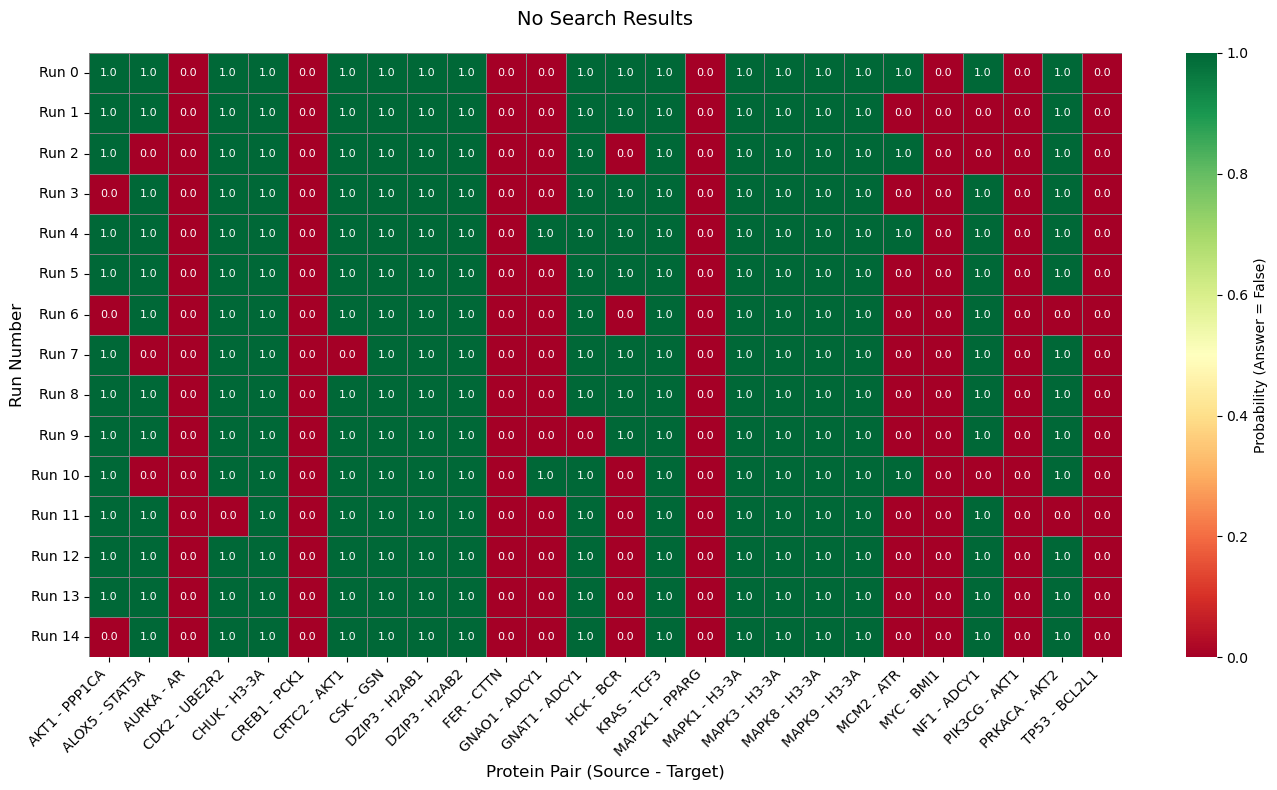

In [ ]:
# Convert no_search_results to a DataFrame for heatmap
gene_pairs = list(no_search_results.keys())

# Sort gene pairs alphabetically
gene_pairs = sorted(gene_pairs, key=lambda x: (x[0], x[1]))

gene_pair_labels = [f"{source} - {target}" for source, target in gene_pairs]
probabilities_no_search = np.array([no_search_results[pair] for pair in gene_pairs])

# Create figure
plt.figure(figsize=(14, 8))

# Create heatmap (transposed) with annotations
sns.heatmap(probabilities_no_search.T,
            xticklabels=gene_pair_labels,
            yticklabels=[f"Run {i}" for i in range(probabilities_no_search.shape[1])],
            cmap='RdYlGn',  # Green for high probability (p=1 is good), Red for low (p=0 is bad)
            vmin=0, vmax=1,
            cbar_kws={'label': 'Probability (Answer = False)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,  # Add numbers to blocks
            fmt='.1f',  # Format numbers to 2 decimal places
            annot_kws={'fontsize': 8})  # Adjust font size for readability

plt.title('No Search Results', fontsize=14, pad=20)
plt.xlabel('Protein Pair (Source - Target)', fontsize=12)
plt.ylabel('Run Number', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('no_search_results_heatmap.png')
plt.show()

In [ ]:
# Accuracy
acc = np.sum(probabilities_no_search>0.5)/probabilities_no_search.size
print(f"Accuracy without search: {acc:.2f}")

Accuracy without search: 0.62


## Plot the distance between the answer and the wrong answer

In [ ]:
no_search_distances = {}
wrong_answers = ['Yes', 'yes', 'YES', 'True', 'true', 'TRUE']
for i in range(len(runs)):
    run = runs[i]
    for result in run:
        source = result['source_node']
        target = result['target_node']
        answer = result['data']['answer']
        logprob = result['data']['logprob']
        
        if answer == False:
            # Find the first wrong answer alternative and calculate distance
            distance = np.nan
            for alt in result['data']['alternatives']:
                if alt['token'] in wrong_answers:
                    alt_logprob = alt['logprob']
                    distance = logprob - alt_logprob
                    break  # Stop after finding the first wrong answer
        else:
            distance = np.nan
        
        # Append to the list for this gene pair
        distance_list = no_search_distances.get((source, target), [])
        distance_list.append(distance)
        no_search_distances[(source, target)] = distance_list

In [ ]:
# Convert no_search_distances to a DataFrame for heatmap
gene_pairs = list(no_search_distances.keys())

# Sort gene pairs alphabetically
gene_pairs = sorted(gene_pairs, key=lambda x: (x[0], x[1]))

gene_pair_labels = [f"{source} - {target}" for source, target in gene_pairs]
distances_no_search = np.array([no_search_distances[pair] for pair in gene_pairs])

# Create figure
plt.figure(figsize=(18, 8))

# Create heatmap (transposed) with annotations
# Higher distance = more confident in correct answer (larger gap between correct and wrong logprob)
sns.heatmap(distances_no_search.T,
            xticklabels=gene_pair_labels,
            yticklabels=[f"Run {i}" for i in range(distances_no_search.shape[1])],
            cmap='RdYlGn',  # Green for high distance (confident), Red for low (uncertain)
            cbar_kws={'label': 'Log Probability Distance (Correct - Wrong)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,  # Add numbers to blocks
            fmt='.1f',  # Format numbers to 1 decimal place
            annot_kws={'fontsize': 8})  # Adjust font size for readability

plt.title('No Search: Log Probability Distance (Correct Answer - Wrong Answer)', 
          fontsize=14, pad=20)
plt.xlabel('Protein Pair (Source - Target)', fontsize=12)
plt.ylabel('Run Number', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('no_search_distances_heatmap.png')
plt.show()

In [ ]:
from scipy import stats

In [ ]:
# plt.hist(avg_distances, bins=10)
# Test if avg_distances follows normal distribution
stats.normaltest(avg_distances)
print(f'Variance of different question: {np.nanvar(avg_distances):.2f}')
# NOTE: It turns out the variance within protein pair are generally higher than the variance between the average values. This means that the differences of the same question but different runs are more variable than the differences between questions, i.e. this means it is pure noise.

Variance of different question: 1.38


In [ ]:
# # Print average distance for each gene pair
# print("Average Distance (Correct - Wrong Answer) for Each Gene Pair:\n")
# print(f"{'Gene Pair':<30} {'Average Distance':>20}")
# print("=" * 55)

# for gene_pair in gene_pairs:
#     distances = no_search_distances[gene_pair]
#     # Calculate mean ignoring NaN values
#     valid_distances = [d for d in distances if not np.isnan(d)]
#     if valid_distances:
#         avg_distance = np.mean(valid_distances)
#         source, target = gene_pair
#         pair_label = f"{source} - {target}"
#         print(f"{pair_label:<30} {avg_distance:>20.2f}")
#     else:
#         source, target = gene_pair
#         pair_label = f"{source} - {target}"
#         print(f"{pair_label:<30} {'N/A':>20}")

# # Overall average
# all_valid_distances = []
# for gene_pair in gene_pairs:
#     distances = no_search_distances[gene_pair]
#     all_valid_distances.extend([d for d in distances if not np.isnan(d)])

# if all_valid_distances:
#     overall_avg = np.mean(all_valid_distances)
#     print("=" * 55)
#     print(f"{'Overall Average':<30} {overall_avg:>20.2f}")

# With search

In [ ]:
def read_all_results(result_dir="./results", num_runs=20):
    """
    Read all result files from multiple runs and extract data.
    
    Returns:
        Dictionary with run numbers as keys, each containing a list of result dictionaries:
        {
            0: [list of results from run 0],
            1: [list of results from run 1],
            ...
        }
        
        Each result dictionary contains:
        - source_node: source gene (from JSON data)
        - target_node: target gene (from JSON data)
        - file_path: path to the JSON file
        - data: the JSON content
    """
    all_runs = {}
    
    for run in range(num_runs):
        run_dir = Path(result_dir) / f"negative_edges_run_{run}"
        
        # Find all JSON files in this run directory
        json_files = glob.glob(str(run_dir / "gene_regulation_result_*_with_search.json"))
        
        run_results = []
        for json_file in json_files:
            try:
                # Read the JSON file
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # Store the result
                result_entry = {
                    'source_node': data.get('source_gene'),
                    'target_node': data.get('target_gene'),
                    'file_path': json_file,
                    'data': data
                }
                run_results.append(result_entry)
                
            except Exception as e:
                print(f"Error processing {json_file}: {e}")
        
        all_runs[run] = run_results
    
    return all_runs

# Load all runs
runs = read_all_results(result_dir="./results", num_runs=14)

In [ ]:
with_search_results = {}
for i in range(len(runs)):
    run = runs[i]
    for result in run:
        source = result['source_node']
        target = result['target_node']
        answer = result['data']['answer']
        if answer == False:
            p = result['data']['probability']
        elif answer == True:
            p = 0.0
        else:
            p = None
        with_search_result = with_search_results.get((source, target), [])
        with_search_result.append(p)
        with_search_results[(source, target)] = with_search_result


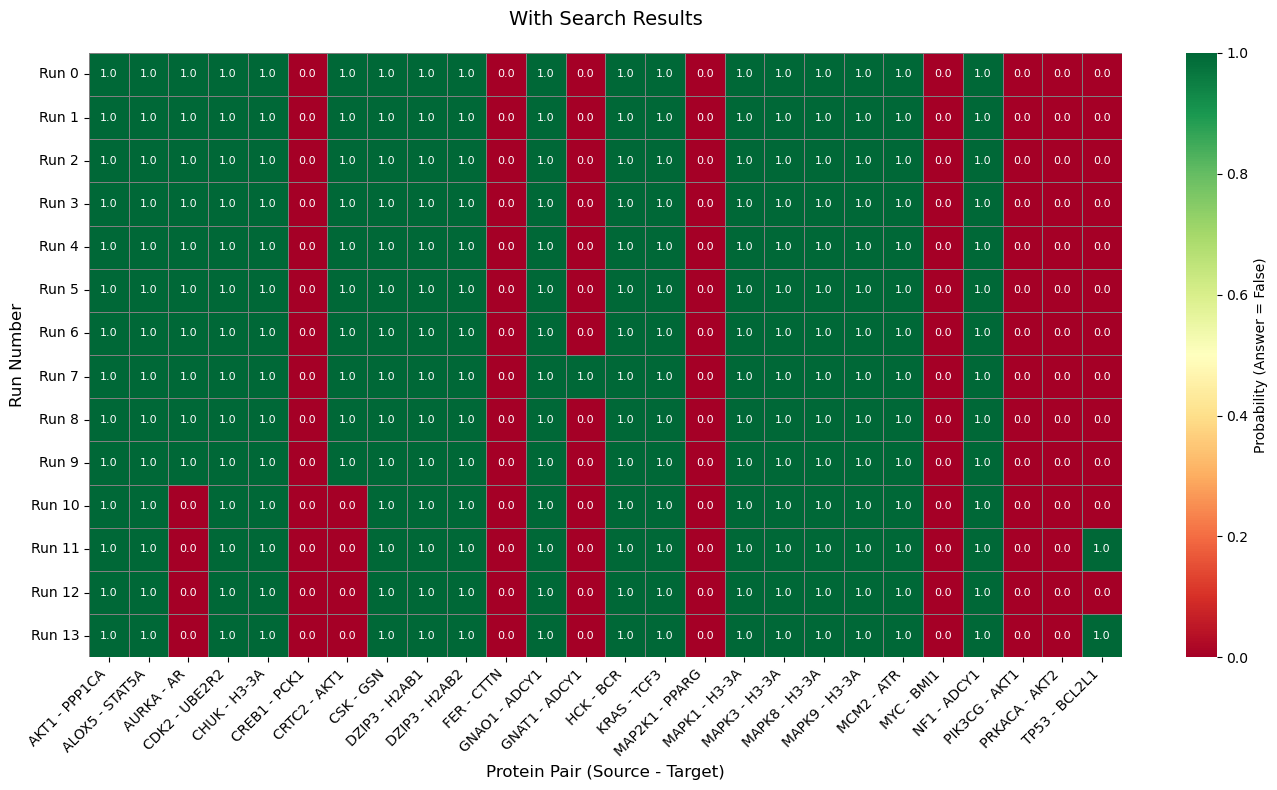

In [ ]:
# Convert with_search_results to a DataFrame for heatmap
gene_pairs = list(with_search_results.keys())

# Sort gene pairs alphabetically
gene_pairs = sorted(gene_pairs, key=lambda x: (x[0], x[1]))

gene_pair_labels = [f"{source} - {target}" for source, target in gene_pairs]
probabilities_with_search = np.array([with_search_results[pair] for pair in gene_pairs])

# Create figure
plt.figure(figsize=(14, 8))

# Create heatmap (transposed) with annotations
sns.heatmap(probabilities_with_search.T,
            xticklabels=gene_pair_labels,
            yticklabels=[f"Run {i}" for i in range(probabilities_with_search.shape[1])],
            cmap='RdYlGn',  # Green for high probability (p=1 is good), Red for low (p=0 is bad)
            vmin=0, vmax=1,
            cbar_kws={'label': 'Probability (Answer = False)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,  # Add numbers to blocks
            fmt='.1f',  # Format numbers to 2 decimal places
            annot_kws={'fontsize': 8})  # Adjust font size for readability

plt.title('With Search Results', fontsize=14, pad=20)
plt.xlabel('Protein Pair (Source - Target)', fontsize=12)
plt.ylabel('Run Number', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# plt.savefig('with_search_results_heatmap.png')
plt.show()

In [ ]:
# Accuracy
acc = np.sum(probabilities_with_search>0.5)/probabilities_with_search.size
print(f"Accuracy with search: {acc:.2f}")

Accuracy with search: 0.68


# Difference (With Search - Without Search)

In [ ]:
# # Calculate the difference: with_search - no_search
# # Positive values mean search improved the probability
# # Negative values mean search decreased the probability
# probability_difference = probabilities_with_search - probabilities_no_search

# # Create figure
# plt.figure(figsize=(14, 8))

# # Create heatmap (transposed) with annotations
# # Use RdBu_r colormap: Red for negative (worse with search), Blue for positive (better with search)
# sns.heatmap(probability_difference.T,
#             xticklabels=gene_pair_labels,
#             yticklabels=[f"Run {i}" for i in range(probability_difference.shape[1])],
#             cmap='RdYlGn',  # Blue for positive (improvement), Red for negative (degradation)
#             center=0,  # Center the colormap at 0
#             vmin=-1, vmax=1,
#             cbar_kws={'label': 'Probability Difference (With Search - No Search)'},
#             linewidths=0.5,
#             linecolor='gray',
#             annot=True,  # Add numbers to blocks
#             fmt='.2f',  # Format numbers to 2 decimal places
#             annot_kws={'fontsize': 8})  # Adjust font size for readability

# plt.title('Difference: With Search - Without Search\n(Green = Improvement, Red = Degradation)', 
#           fontsize=14, pad=20)
# plt.xlabel('Protein Pair (Source - Target)', fontsize=12)
# plt.ylabel('Run Number', fontsize=12)
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()

# plt.savefig('probability_difference_heatmap.png')
# plt.show()

# Plot the token logprobs

In [ ]:
# # Load a single JSON file and visualize token logprobs
# import matplotlib.pyplot as plt
# from matplotlib.colors import Normalize
# import numpy as np
# import json
# from IPython.display import HTML, display

# # Load the JSON file
# file_path = 'llm_response_CSK_GSN.json'
# with open(file_path, 'r') as f:
#     data = json.load(f)

# # Extract tokens and logprobs
# tokens = []
# logprobs = []

# for item in data['completion_probabilities']:
#     tokens.append(item['token'])
#     logprobs.append(item['logprob'])

# # Convert to numpy array
# logprobs = np.array(logprobs)

# # Convert logprobs to probabilities (no normalization needed!)
# probabilities = np.exp(logprobs)

# print(f"Total tokens: {len(tokens)}")
# print(f"Logprob range: [{logprobs.min():.2f}, {logprobs.max():.2f}]")
# print(f"Probability range: [{probabilities.min():.4f}, {probabilities.max():.4f}]")

# # Create a colormap - higher probability = lighter color
# cmap = plt.cm.RdYlGn

# # Create HTML visualization with colored tokens
# html_parts = ['<div style="font-family: monospace; font-size: 14px; line-height: 1.8; padding: 20px; background-color: #f5f5f5;">']

# for i, (token, logprob, prob) in enumerate(zip(tokens, logprobs, probabilities)):
#     # Get color for this probability (prob is already in [0, 1])
#     rgba = cmap(prob)
#     rgb_hex = '#{:02x}{:02x}{:02x}'.format(int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))
    
#     # Escape HTML special characters
#     token_escaped = token.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;').replace(' ', '&nbsp;')
    
#     # Add colored span for each token
#     html_parts.append(f'<span style="background-color: {rgb_hex}; padding: 2px 1px;" title="probability: {prob:.4f}, logprob: {logprob:.4f}">{token_escaped}</span>')

# html_parts.append('</div>')

# # Display the HTML
# html_output = ''.join(html_parts)
# display(HTML(html_output))
# # save the HTML output to a file
# with open('llm_response_CSK_GSN.html', 'w') as f:
#     f.write(html_output)

# # # Also create a matplotlib figure with colorbar legend
# # fig, ax = plt.subplots(figsize=(10, 1))
# # fig.subplots_adjust(bottom=0.5)

# # norm = Normalize(vmin=0, vmax=1)
# # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# # sm.set_array([])

# # cbar = plt.colorbar(sm, cax=ax, orientation='horizontal')
# # cbar.set_label('Probability (Higher = More Confident)', fontsize=12)
# # ax.set_title('Color Scale: Lighter = Higher Probability (More Confident)', fontsize=10, pad=10)

# # plt.tight_layout()

# # plt.show()

# # NOTE: The second Yes in "So answer Yes" has a lower probability (logprob -0.083 (p=0.92)). But the alternatives are all Yes or some other notations.
# # There is no other No answer. So, it doesn't really show how confident the LLM is.

# p(True)

## Without search

In [ ]:
result_path = Path("./results/llm_confidence_combined_results_no_search.json")
with open(result_path, 'r') as f:
    combined_results_no_search = json.load(f)

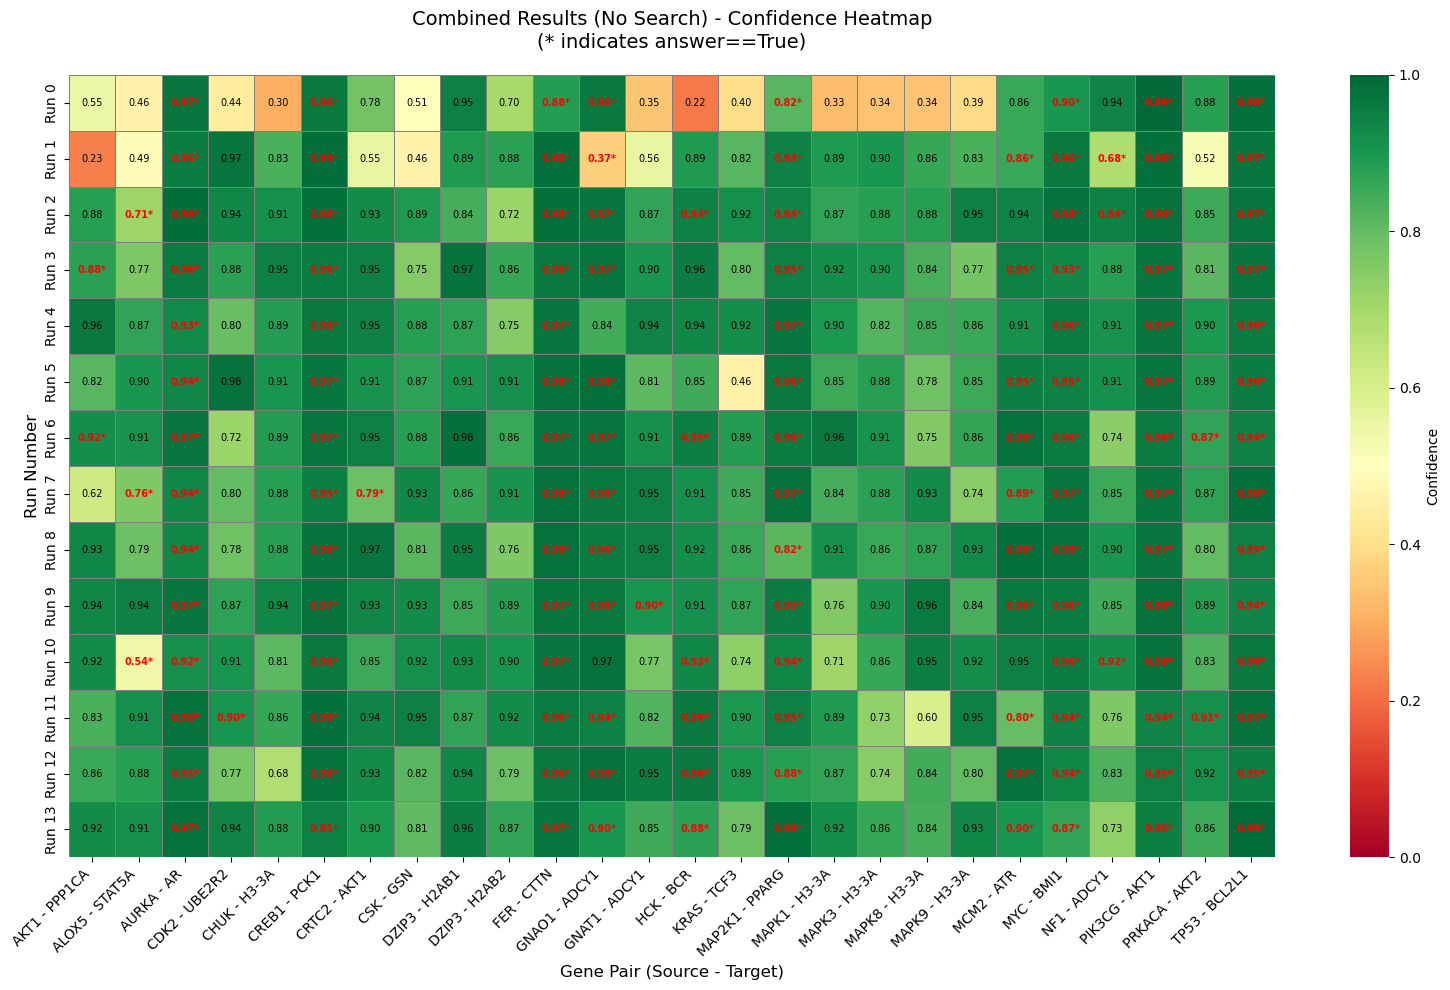


Number of gene pairs: 26
Number of runs per pair: 14
Number of answer==True cases: 139

Overall statistics:
  Mean confidence: 0.872
  Std confidence: 0.134
  Min confidence: 0.221
  Max confidence: 0.994


In [ ]:
# Plot heatmap for combined_results_no_search with marking for answer==True cases

# First, we need to load the raw data to check which entries had answer==True
def read_all_results_with_answers(result_dir="./results", num_runs=20):
    """Read results and track which had answer==True"""
    all_answers = {}
    
    for run in range(num_runs):
        run_dir = Path(result_dir) / f"negative_edges_run_{run}"
        json_files = glob.glob(str(run_dir / "gene_regulation_result_*_no_search.json"))
        
        for json_file in json_files:
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                source = data.get('source_gene')
                target = data.get('target_gene')
                answer = data.get('answer')
                
                key = (source, target, run)
                all_answers[key] = (answer == True)
                
            except Exception as e:
                print(f"Error processing {json_file}: {e}")
    
    return all_answers

# Load answer data
answer_data = read_all_results_with_answers(result_dir="./results", num_runs=15)

# Parse the keys to get source and target genes
gene_pairs_combined = []
for key in combined_results_no_search.keys():
    source, target = key.split('_')
    gene_pairs_combined.append((source, target))

# Sort gene pairs alphabetically
gene_pairs_combined = sorted(gene_pairs_combined, key=lambda x: (x[0], x[1]))

# Create labels and data matrix
gene_pair_labels_combined = [f"{source} - {target}" for source, target in gene_pairs_combined]
confidence_matrix = np.array([combined_results_no_search[f"{source}_{target}"] for source, target in gene_pairs_combined])

# Create a mask for cells where answer==True
true_answer_mask = np.zeros_like(confidence_matrix, dtype=bool)
for i, (source, target) in enumerate(gene_pairs_combined):
    for run in range(confidence_matrix.shape[1]):
        key = (source, target, run)
        if key in answer_data and answer_data[key]:
            true_answer_mask[i, run] = True

# Create figure with custom annotations
fig, ax = plt.subplots(figsize=(16, 10))

# Create heatmap (transposed) with annotations
sns.heatmap(confidence_matrix.T,
            xticklabels=gene_pair_labels_combined,
            yticklabels=[f"Run {i}" for i in range(confidence_matrix.shape[1])],
            cmap='RdYlGn',  # Red for low confidence, Green for high confidence
            vmin=0, vmax=1,
            cbar_kws={'label': 'Confidence'},
            linewidths=0.5,
            linecolor='gray',
            annot=False,  # We'll add custom annotations
            ax=ax)

# Add custom annotations with markers for answer==True
for i, (source, target) in enumerate(gene_pairs_combined):
    for run in range(confidence_matrix.shape[1]):
        value = confidence_matrix[i, run]
        # Check if this cell had answer==True
        is_true_answer = true_answer_mask[i, run]
        
        if is_true_answer:
            # Mark with asterisk for answer==True cases
            text = f"{value:.2f}*"
            color = 'red'
            weight = 'bold'
        else:
            text = f"{value:.2f}"
            color = 'black'
            weight = 'normal'
        
        ax.text(i + 0.5, run + 0.5, text,
                ha='center', va='center',
                fontsize=7, color=color, weight=weight)

plt.title('Combined Results (No Search) - Confidence Heatmap\n(* indicates answer==True)', 
          fontsize=14, pad=20)
plt.xlabel('Gene Pair (Source - Target)', fontsize=12)
plt.ylabel('Run Number', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# plt.savefig('combined_results_no_search_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print(f"\nNumber of gene pairs: {len(gene_pairs_combined)}")
print(f"Number of runs per pair: {confidence_matrix.shape[1]}")
print(f"Number of answer==True cases: {true_answer_mask.sum()}")
print(f"\nOverall statistics:")
print(f"  Mean confidence: {np.mean(confidence_matrix):.3f}")
print(f"  Std confidence: {np.std(confidence_matrix):.3f}")
print(f"  Min confidence: {np.min(confidence_matrix):.3f}")
print(f"  Max confidence: {np.max(confidence_matrix):.3f}")

## Without search

In [ ]:
result_path = Path("./results/llm_confidence_combined_results_with_search.json")
with open(result_path, 'r') as f:
    combined_results_with_search = json.load(f)

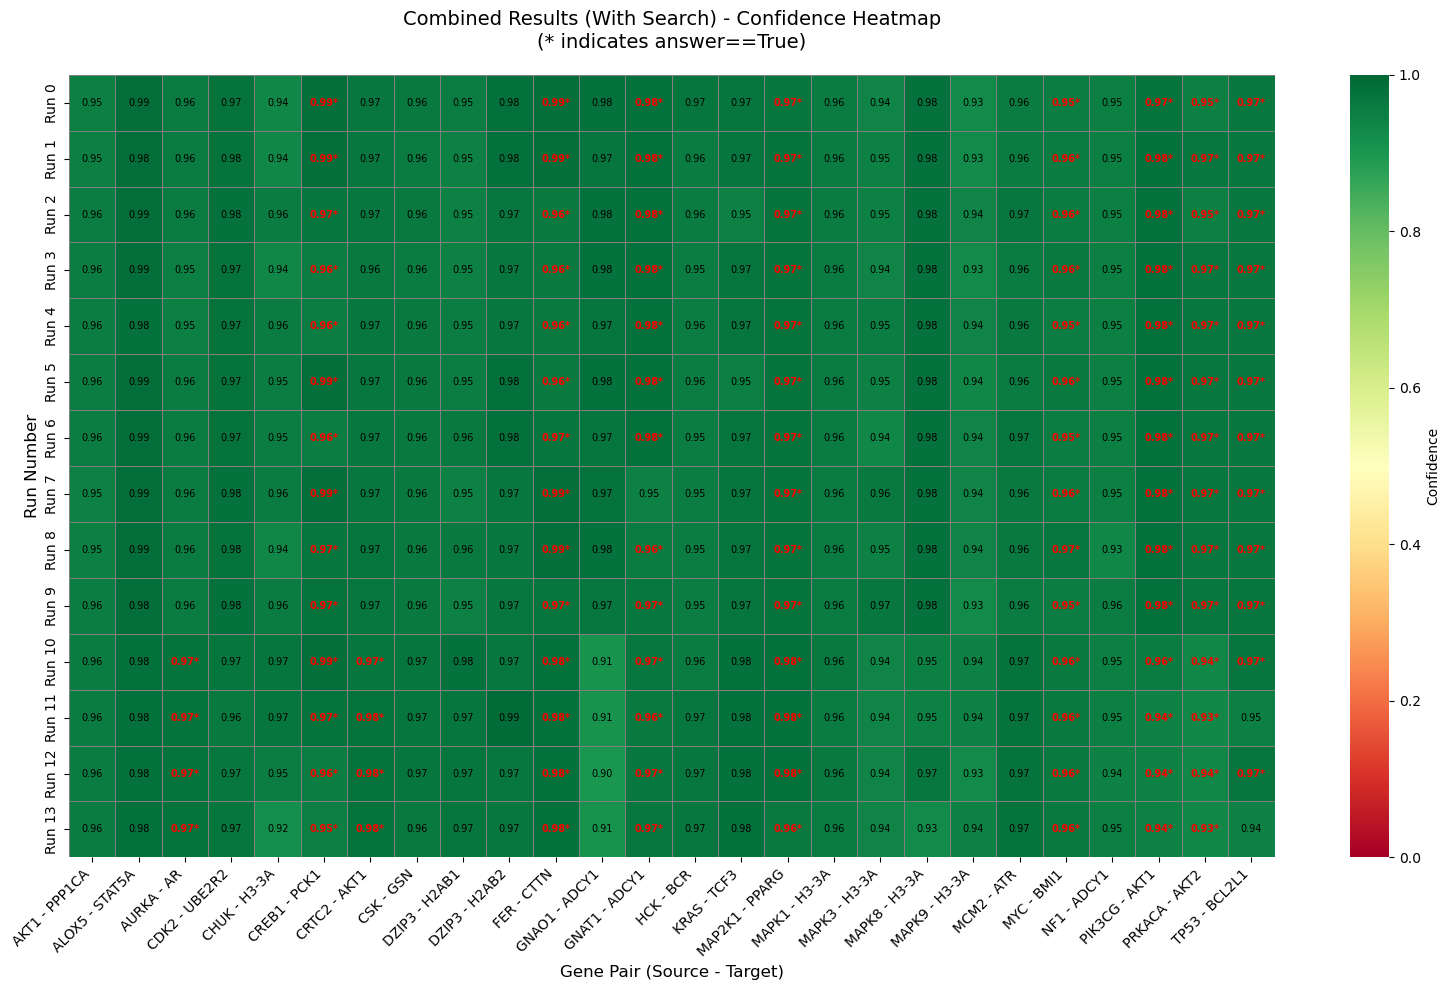


Number of gene pairs: 26
Maximum number of runs per pair: 14
Number of answer==True cases: 117

Overall statistics (excluding NaN values):
  Mean confidence: 0.963
  Std confidence: 0.015
  Min confidence: 0.900
  Max confidence: 0.991


In [ ]:
# Plot heatmap for combined_results_with_search with marking for answer==True cases

# First, we need to load the raw data to check which entries had answer==True
def read_all_results_with_answers_search(result_dir="./results", num_runs=20):
    """Read results and track which had answer==True"""
    all_answers = {}
    
    for run in range(num_runs):
        run_dir = Path(result_dir) / f"negative_edges_run_{run}"
        json_files = glob.glob(str(run_dir / "gene_regulation_result_*_with_search.json"))
        
        for json_file in json_files:
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                source = data.get('source_gene')
                target = data.get('target_gene')
                answer = data.get('answer')
                
                key = (source, target, run)
                all_answers[key] = (answer == True)
                
            except Exception as e:
                print(f"Error processing {json_file}: {e}")
    
    return all_answers

# Load answer data for with_search
answer_data_search = read_all_results_with_answers_search(result_dir="./results", num_runs=15)

# Parse the keys to get source and target genes
gene_pairs_combined = []
for key in combined_results_with_search.keys():
    source, target = key.split('_')
    gene_pairs_combined.append((source, target))

# Sort gene pairs alphabetically
gene_pairs_combined = sorted(gene_pairs_combined, key=lambda x: (x[0], x[1]))

# Create labels and data matrix
gene_pair_labels_combined = [f"{source} - {target}" for source, target in gene_pairs_combined]

# Find the maximum number of runs across all gene pairs
max_runs = max(len(combined_results_with_search[f"{source}_{target}"]) for source, target in gene_pairs_combined)

# Create a padded matrix with NaN for missing values
confidence_matrix = []
for source, target in gene_pairs_combined:
    values = combined_results_with_search[f"{source}_{target}"]
    # Pad with NaN if needed
    padded_values = values + [np.nan] * (max_runs - len(values))
    confidence_matrix.append(padded_values)

confidence_matrix = np.array(confidence_matrix)

# Create a mask for cells where answer==True
true_answer_mask = np.zeros_like(confidence_matrix, dtype=bool)
for i, (source, target) in enumerate(gene_pairs_combined):
    for run in range(confidence_matrix.shape[1]):
        key = (source, target, run)
        if key in answer_data_search and answer_data_search[key]:
            true_answer_mask[i, run] = True

# Create figure with custom annotations
fig, ax = plt.subplots(figsize=(16, 10))

# Create heatmap (transposed) with annotations
sns.heatmap(confidence_matrix.T,
            xticklabels=gene_pair_labels_combined,
            yticklabels=[f"Run {i}" for i in range(confidence_matrix.shape[1])],
            cmap='RdYlGn',  # Red for low confidence, Green for high confidence
            vmin=0, vmax=1,
            cbar_kws={'label': 'Confidence'},
            linewidths=0.5,
            linecolor='gray',
            annot=False,  # We'll add custom annotations
            ax=ax)

# Add custom annotations with markers for answer==True
for i, (source, target) in enumerate(gene_pairs_combined):
    for run in range(confidence_matrix.shape[1]):
        value = confidence_matrix[i, run]
        
        # Skip NaN values
        if np.isnan(value):
            continue
            
        # Check if this cell had answer==True
        is_true_answer = true_answer_mask[i, run]
        
        if is_true_answer:
            # Mark with asterisk for answer==True cases
            text = f"{value:.2f}*"
            color = 'red'
            weight = 'bold'
        else:
            text = f"{value:.2f}"
            color = 'black'
            weight = 'normal'
        
        ax.text(i + 0.5, run + 0.5, text,
                ha='center', va='center',
                fontsize=7, color=color, weight=weight)

plt.title('Combined Results (With Search) - Confidence Heatmap\n(* indicates answer==True)', 
          fontsize=14, pad=20)
plt.xlabel('Gene Pair (Source - Target)', fontsize=12)
plt.ylabel('Run Number', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# plt.savefig('combined_results_with_search_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print(f"\nNumber of gene pairs: {len(gene_pairs_combined)}")
print(f"Maximum number of runs per pair: {confidence_matrix.shape[1]}")
print(f"Number of answer==True cases: {true_answer_mask.sum()}")
print(f"\nOverall statistics (excluding NaN values):")
print(f"  Mean confidence: {np.nanmean(confidence_matrix):.3f}")
print(f"  Std confidence: {np.nanstd(confidence_matrix):.3f}")
print(f"  Min confidence: {np.nanmin(confidence_matrix):.3f}")
print(f"  Max confidence: {np.nanmax(confidence_matrix):.3f}")

# Benchmark True and Fase prediction result

In [3]:
# Load ground truth edges
# False edges
false_edges = pd.read_csv('../all_removed_edges_with_sources.csv')
# Extract only the protein-protein interactions
false_edges = false_edges[(false_edges['TYPEA'] == 'protein') & (false_edges['TYPEB'] == 'protein')]
# Remove duplicates
false_edges = false_edges[['ENTITYA', 'ENTITYB', 'EFFECT']].drop_duplicates()
# Add label column
false_edges['label'] = 'false'

# True edges
true_edges = pd.read_csv('../ground_truth_data/true_edges.csv')
true_edges = true_edges[['ENTITYA', 'ENTITYB', 'EFFECT']].drop_duplicates()
true_edges['label'] = 'true'
# Ensure number of true edges is the same as false edges, sampele the first N true edges
true_edges = true_edges.head(len(false_edges))

# Combine false and true edges
all_ground_truth_edges = pd.concat([false_edges, true_edges], ignore_index=True)

In [4]:
# Loop through the edges prediction results
REPEAT = 10
model = 'gpt-oss-120b'
# model = 'glm-4.6'
edges_all = all_ground_truth_edges.copy(deep=True)

# Initialize answer columns for each repeat
for repeat in range(REPEAT):
    edges_all[f'answer_{repeat}'] = None

for index, edge in all_ground_truth_edges.iterrows():
    # Get the edge data
    source = edge['ENTITYA']
    target = edge['ENTITYB']
    label = edge['label']
    
    for repeat in range(REPEAT):
        # False edges prediction
        if label == 'false':
            result_file = Path(f'./results/reasoning/{model}/no_search/false_edges/{source}_{target}_repeat{repeat}.json')
        else:  # True edges
            result_file = Path(f'./results/reasoning/{model}/no_search/true_edges/{source}_{target}_repeat{repeat}.json')
        
        # Check if file exists
        if result_file.exists():
            with open(result_file, 'r') as f:
                result_data = json.load(f)
            answer = result_data['answer']
            # Store answer in the DataFrame
            edges_all.loc[index, f'answer_{repeat}'] = answer
        else:
            print(f"File not found: {result_file}")

In [5]:
# Check is there any NaN values in the answers
nan_counts = edges_all[[f'answer_{repeat}' for repeat in range(REPEAT)]].isna().sum()
print("NaN counts in answers for each repeat:")
print(nan_counts)

NaN counts in answers for each repeat:
answer_0    0
answer_1    0
answer_2    0
answer_3    0
answer_4    0
answer_5    0
answer_6    0
answer_7    0
answer_8    0
answer_9    0
dtype: int64


0     0.0
1     0.0
2     1.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     1.0
10    0.0
11    0.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
18    0.0
19    0.0
20    0.0
21    0.0
22    0.0
23    0.0
24    0.0
25    0.0
26    1.0
27    1.0
28    1.0
29    1.0
30    0.0
31    0.0
32    0.0
33    0.0
34    0.0
35    0.0
36    1.0
37    1.0
38    0.0
39    1.0
40    1.0
41    0.0
42    0.0
43    0.0
44    1.0
45    0.0
46    0.0
47    0.0
48    1.0
49    1.0
50    1.0
51    1.0
Name: answer_0, dtype: float64
0     0.0
1     0.0
2     1.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     1.0
10    0.0
11    0.0
12    1.0
13    0.0
14    1.0
15    1.0
16    1.0
17    1.0
18    0.0
19    0.0
20    0.0
21    0.0
22    0.0
23    0.0
24    0.0
25    0.0
26    1.0
27    1.0
28    1.0
29    1.0
30    0.0
31    0.0
32    0.0
33    0.0
34    1.0
35    0.0
36    1.0
37    1.0
38    0.0
39    1.0
40    1.0
41    0.0
42    0.0
43    0.0
44    1.0

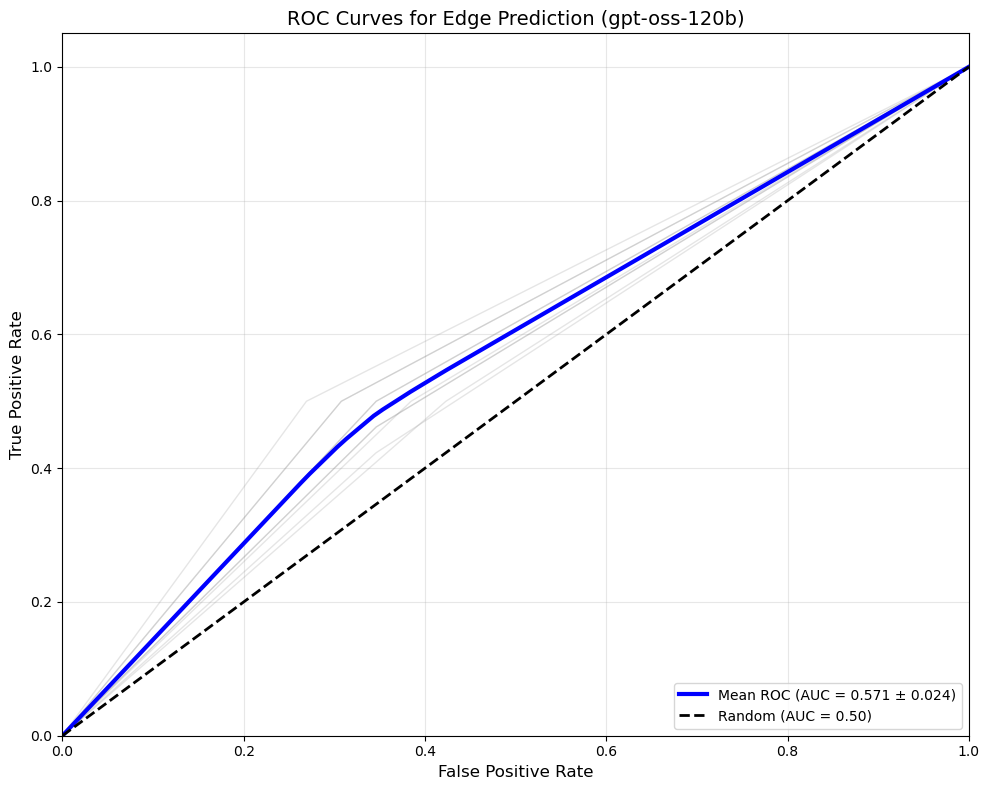


Individual AUC scores: ['0.596', '0.615', '0.577', '0.538', '0.558', '0.577', '0.538', '0.558', '0.596', '0.558']
Mean AUC: 0.571 ± 0.024
Mean curve AUC: 0.571


In [6]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Prepare data for ROC curve
# Convert label to binary: 'true' = 1, 'false' = 0
y_true = (edges_all['label'] == 'true').astype(int)

# Create figure for ROC curves
plt.figure(figsize=(10, 8))

# Store all FPR and TPR values for averaging
all_fprs = []
all_tprs = []

# Plot ROC curve for each repeat
auc_scores = []
for repeat in range(REPEAT):
    # Get predictions for this repeat
    # Convert answer to probability: True = 1.0, False = 0.0
    y_pred = edges_all[f'answer_{repeat}'].apply(lambda x: 1.0 if x == True else 0.0)
    
    # Remove rows with missing predictions
    valid_mask = ~y_pred.isna()
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]
    
    # Calculate ROC curve
    print(y_pred_valid)
    fpr, tpr, thresholds = roc_curve(y_true_valid, y_pred_valid)
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    
    # Store for averaging
    all_fprs.append(fpr)
    all_tprs.append(tpr)
    
    # Plot individual curves with low alpha
    plt.plot(fpr, tpr, alpha=0.2, color='gray', linewidth=1)

# Compute mean ROC curve by vertical averaging
# Create a common set of FPR points
mean_fpr = np.linspace(0, 1, 100)

# Interpolate TPR values at these FPR points for each repeat
interpolated_tprs = []
for fpr, tpr in zip(all_fprs, all_tprs):
    # Use numpy interp to get TPR at mean_fpr points
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interpolated_tprs.append(interp_tpr)

# Calculate mean and std TPR
mean_tpr = np.mean(interpolated_tprs, axis=0)
std_tpr = np.std(interpolated_tprs, axis=0)

# Ensure the curve starts at (0,0) and ends at (1,1)
mean_tpr[0] = 0.0
mean_tpr[-1] = 1.0

# Calculate AUC for mean curve
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b', linewidth=3, 
         label=f'Mean ROC (AUC = {mean_auc:.3f} ± {np.std(auc_scores):.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curves for Edge Prediction ({model})', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
# plt.savefig(f'roc_curve_mean_{model}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nIndividual AUC scores: {[f'{score:.3f}' for score in auc_scores]}")
print(f"Mean AUC: {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
print(f"Mean curve AUC: {mean_auc:.3f}")

In [7]:
# Load data for glm-4.6 model
REPEAT_GLM = 10
model_glm = 'glm-4.6'
edges_all_glm = all_ground_truth_edges.copy(deep=True)

# Initialize answer columns for each repeat
for repeat in range(REPEAT_GLM):
    edges_all_glm[f'answer_{repeat}'] = None

for index, edge in all_ground_truth_edges.iterrows():
    # Get the edge data
    source = edge['ENTITYA']
    target = edge['ENTITYB']
    label = edge['label']
    
    for repeat in range(REPEAT_GLM):
        # False edges prediction
        if label == 'false':
            result_file = Path(f'./results/reasoning/{model_glm}/no_search/false_edges/{source}_{target}_repeat{repeat}.json')
        else:  # True edges
            result_file = Path(f'./results/reasoning/{model_glm}/no_search/true_edges/{source}_{target}_repeat{repeat}.json')
        
        # Check if file exists
        if result_file.exists():
            with open(result_file, 'r') as f:
                result_data = json.load(f)
            answer = result_data['answer']
            # Store answer in the DataFrame
            edges_all_glm.loc[index, f'answer_{repeat}'] = answer
        else:
            print(f"File not found: {result_file}")

# Check for NaN values
nan_counts_glm = edges_all_glm[[f'answer_{repeat}' for repeat in range(REPEAT_GLM)]].isna().sum()
print("NaN counts in answers for each repeat (GLM-4.6):")
print(nan_counts_glm)

File not found: results/reasoning/glm-4.6/no_search/false_edges/DZIP3_H2AB1_repeat1.json
File not found: results/reasoning/glm-4.6/no_search/false_edges/DZIP3_H2AB1_repeat2.json
File not found: results/reasoning/glm-4.6/no_search/false_edges/DZIP3_H2AB1_repeat3.json
File not found: results/reasoning/glm-4.6/no_search/false_edges/DZIP3_H2AB1_repeat4.json
File not found: results/reasoning/glm-4.6/no_search/false_edges/DZIP3_H2AB1_repeat5.json
File not found: results/reasoning/glm-4.6/no_search/false_edges/DZIP3_H2AB1_repeat6.json
File not found: results/reasoning/glm-4.6/no_search/false_edges/DZIP3_H2AB1_repeat7.json
File not found: results/reasoning/glm-4.6/no_search/false_edges/DZIP3_H2AB1_repeat8.json
File not found: results/reasoning/glm-4.6/no_search/false_edges/DZIP3_H2AB1_repeat9.json
File not found: results/reasoning/glm-4.6/no_search/false_edges/KRAS_TCF3_repeat0.json
File not found: results/reasoning/glm-4.6/no_search/false_edges/KRAS_TCF3_repeat1.json
File not found: results/r

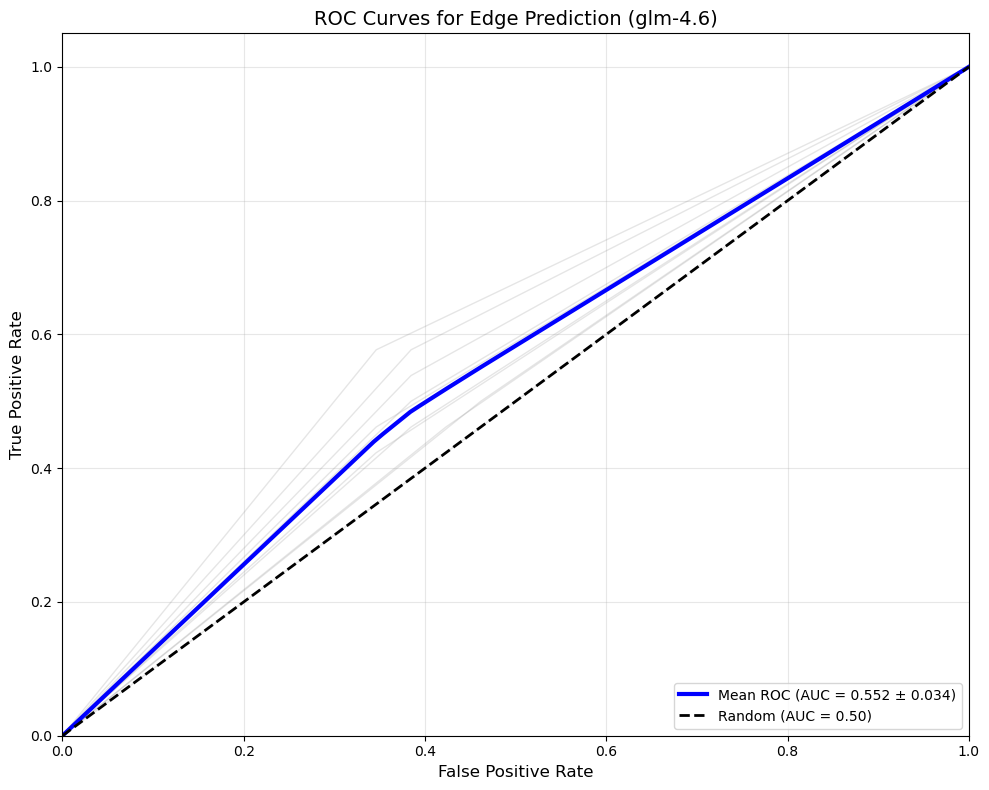


Individual AUC scores: ['0.596', '0.519', '0.577', '0.519', '0.615', '0.558', '0.558', '0.500', '0.538', '0.538']
Mean AUC: 0.552 ± 0.034
Mean curve AUC: 0.552


In [8]:
# Plot ROC curve for glm-4.6 model
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Prepare data for ROC curve
y_true_glm = (edges_all_glm['label'] == 'true').astype(int)

# Create figure for ROC curves
plt.figure(figsize=(10, 8))

# Store all FPR and TPR values for averaging
all_fprs_glm = []
all_tprs_glm = []

# Plot ROC curve for each repeat
auc_scores_glm = []
for repeat in range(REPEAT_GLM):
    # Get predictions for this repeat
    y_pred = edges_all_glm[f'answer_{repeat}'].apply(lambda x: 1.0 if x == True else 0.0)
    
    # Remove rows with missing predictions
    valid_mask = ~y_pred.isna()
    y_true_valid = y_true_glm[valid_mask]
    y_pred_valid = y_pred[valid_mask]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true_valid, y_pred_valid)
    roc_auc = auc(fpr, tpr)
    auc_scores_glm.append(roc_auc)
    
    # Store for averaging
    all_fprs_glm.append(fpr)
    all_tprs_glm.append(tpr)
    
    # Plot individual curves with low alpha
    plt.plot(fpr, tpr, alpha=0.2, color='gray', linewidth=1)

# Compute mean ROC curve by vertical averaging
mean_fpr_glm = np.linspace(0, 1, 100)

# Interpolate TPR values at these FPR points for each repeat
interpolated_tprs_glm = []
for fpr, tpr in zip(all_fprs_glm, all_tprs_glm):
    interp_tpr = np.interp(mean_fpr_glm, fpr, tpr)
    interpolated_tprs_glm.append(interp_tpr)

# Calculate mean and std TPR
mean_tpr_glm = np.mean(interpolated_tprs_glm, axis=0)
std_tpr_glm = np.std(interpolated_tprs_glm, axis=0)

# Ensure the curve starts at (0,0) and ends at (1,1)
mean_tpr_glm[0] = 0.0
mean_tpr_glm[-1] = 1.0

# Calculate AUC for mean curve
mean_auc_glm = auc(mean_fpr_glm, mean_tpr_glm)

# Plot mean ROC curve
plt.plot(mean_fpr_glm, mean_tpr_glm, color='b', linewidth=3, 
         label=f'Mean ROC (AUC = {mean_auc_glm:.3f} ± {np.std(auc_scores_glm):.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curves for Edge Prediction ({model_glm})', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
# plt.savefig(f'roc_curve_mean_{model_glm}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nIndividual AUC scores: {[f'{score:.3f}' for score in auc_scores_glm]}")
print(f"Mean AUC: {np.mean(auc_scores_glm):.3f} ± {np.std(auc_scores_glm):.3f}")
print(f"Mean curve AUC: {mean_auc_glm:.3f}")

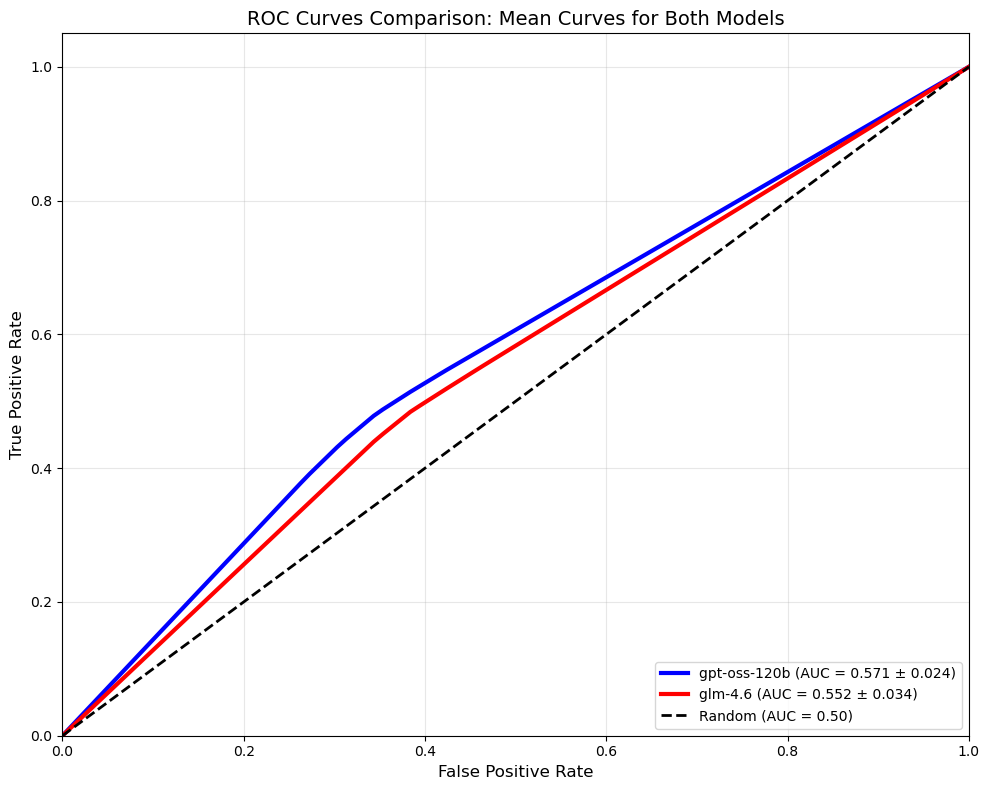


Model Comparison:

gpt-oss-120b:
  Mean AUC: 0.571 ± 0.024
  Mean curve AUC: 0.571

glm-4.6:
  Mean AUC: 0.552 ± 0.034
  Mean curve AUC: 0.552



In [9]:
# Combined plot with both models' average ROC curves
plt.figure(figsize=(10, 8))

# Plot gpt-oss-120b mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b', linewidth=3, 
         label=f'{model} (AUC = {mean_auc:.3f} ± {np.std(auc_scores):.3f})')

# Plot glm-4.6 mean ROC curve
plt.plot(mean_fpr_glm, mean_tpr_glm, color='r', linewidth=3, 
         label=f'{model_glm} (AUC = {mean_auc_glm:.3f} ± {np.std(auc_scores_glm):.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison: Mean Curves for Both Models', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
# plt.savefig('roc_curve_comparison_both_models.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison statistics
print(f"\n{'='*60}")
print(f"Model Comparison:")
print(f"{'='*60}")
print(f"\n{model}:")
print(f"  Mean AUC: {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")
print(f"  Mean curve AUC: {mean_auc:.3f}")
print(f"\n{model_glm}:")
print(f"  Mean AUC: {np.mean(auc_scores_glm):.3f} ± {np.std(auc_scores_glm):.3f}")
print(f"  Mean curve AUC: {mean_auc_glm:.3f}")
print(f"\n{'='*60}")

# Filter data to remove missing edges in GLM-4.6

In [10]:
# Step 1: Identify missing edges from GLM-4.6 model
missing_edges = []

for index, edge in all_ground_truth_edges.iterrows():
    source = edge['ENTITYA']
    target = edge['ENTITYB']
    label = edge['label']
    
    # Check if any repeat is missing for this edge in GLM-4.6
    missing_count = 0
    for repeat in range(REPEAT_GLM):
        if label == 'false':
            result_file = Path(f'./results/reasoning/{model_glm}/no_search/false_edges/{source}_{target}_repeat{repeat}.json')
        else:  # True edges
            result_file = Path(f'./results/reasoning/{model_glm}/no_search/true_edges/{source}_{target}_repeat{repeat}.json')
        
        if not result_file.exists():
            missing_count += 1
    
    # If more than half of repeats are missing, mark this edge for removal
    if missing_count > REPEAT_GLM / 2:
        missing_edges.append((source, target, label, missing_count))

print(f"Found {len(missing_edges)} edges with significant missing data in GLM-4.6:")
for source, target, label, count in missing_edges:
    print(f"  {source} - {target} (label: {label}): {count}/{REPEAT_GLM} missing")

Found 2 edges with significant missing data in GLM-4.6:
  DZIP3 - H2AB1 (label: false): 9/10 missing
  KRAS - TCF3 (label: false): 10/10 missing


In [11]:
# Step 2: Remove missing edges from all_ground_truth_edges
all_ground_truth_edges_filtered = all_ground_truth_edges.copy()

# Count how many false edges we're removing
num_false_edges_to_remove = sum(1 for _, _, label, _ in missing_edges if label == 'false')
print(f"Number of false edges to remove: {num_false_edges_to_remove}")

# Remove the missing false edges
for source, target, label, _ in missing_edges:
    mask = (all_ground_truth_edges_filtered['ENTITYA'] == source) & \
           (all_ground_truth_edges_filtered['ENTITYB'] == target) & \
           (all_ground_truth_edges_filtered['label'] == label)
    all_ground_truth_edges_filtered = all_ground_truth_edges_filtered[~mask]

# Also remove the same number of true edges (from the end) to maintain balance
if num_false_edges_to_remove > 0:
    true_edges_mask = all_ground_truth_edges_filtered['label'] == 'true'
    true_edge_indices = all_ground_truth_edges_filtered[true_edges_mask].index

    # Get the last N true edges
    true_edges_to_remove = true_edge_indices[-num_false_edges_to_remove:]

    print(f"\nRemoving {num_false_edges_to_remove} true edges (last ones) to maintain balance:")
    for idx in true_edges_to_remove:
        edge = all_ground_truth_edges_filtered.loc[idx]
        print(f"  {edge['ENTITYA']} - {edge['ENTITYB']}")

    # Remove the last N true edges
    all_ground_truth_edges_filtered = all_ground_truth_edges_filtered.drop(true_edges_to_remove)

print(f"\n{'='*60}")
print(f"Original edges: {len(all_ground_truth_edges)}")
print(f"Filtered edges: {len(all_ground_truth_edges_filtered)}")
print(f"Removed: {len(all_ground_truth_edges) - len(all_ground_truth_edges_filtered)} edges")
print(f"  - False edges removed: {num_false_edges_to_remove}")
print(f"  - True edges removed: {num_false_edges_to_remove}")
print(f"{'='*60}")

Number of false edges to remove: 2

Removing 2 true edges (last ones) to maintain balance:
  CEP192 - AURKA
  UBAP2L - BMI1

Original edges: 52
Filtered edges: 48
Removed: 4 edges
  - False edges removed: 2
  - True edges removed: 2


## Reload GPT-OSS-120B with filtered data

In [12]:
# Step 3: Reload GPT-OSS-120B data with filtered ground truth
edges_all_filtered = all_ground_truth_edges_filtered.copy(deep=True)

# Initialize answer columns for each repeat
for repeat in range(REPEAT):
    edges_all_filtered[f'answer_{repeat}'] = None

for index, edge in all_ground_truth_edges_filtered.iterrows():
    # Get the edge data
    source = edge['ENTITYA']
    target = edge['ENTITYB']
    label = edge['label']
    
    for repeat in range(REPEAT):
        # False edges prediction
        if label == 'false':
            result_file = Path(f'./results/reasoning/{model}/no_search/false_edges/{source}_{target}_repeat{repeat}.json')
        else:  # True edges
            result_file = Path(f'./results/reasoning/{model}/no_search/true_edges/{source}_{target}_repeat{repeat}.json')
        
        # Check if file exists
        if result_file.exists():
            with open(result_file, 'r') as f:
                result_data = json.load(f)
            answer = result_data['answer']
            # Store answer in the DataFrame
            edges_all_filtered.loc[index, f'answer_{repeat}'] = answer
        else:
            print(f"File not found: {result_file}")

# Check for NaN values
nan_counts_filtered = edges_all_filtered[[f'answer_{repeat}' for repeat in range(REPEAT)]].isna().sum()
print("NaN counts in answers for each repeat (GPT-OSS-120B filtered):")
print(nan_counts_filtered)

NaN counts in answers for each repeat (GPT-OSS-120B filtered):
answer_0    0
answer_1    0
answer_2    0
answer_3    0
answer_4    0
answer_5    0
answer_6    0
answer_7    0
answer_8    0
answer_9    0
dtype: int64


Loaded 67 GNN predictions
Matched 48 edges between GNN predictions and edges_all_filtered
True edges: 24
False edges: 24


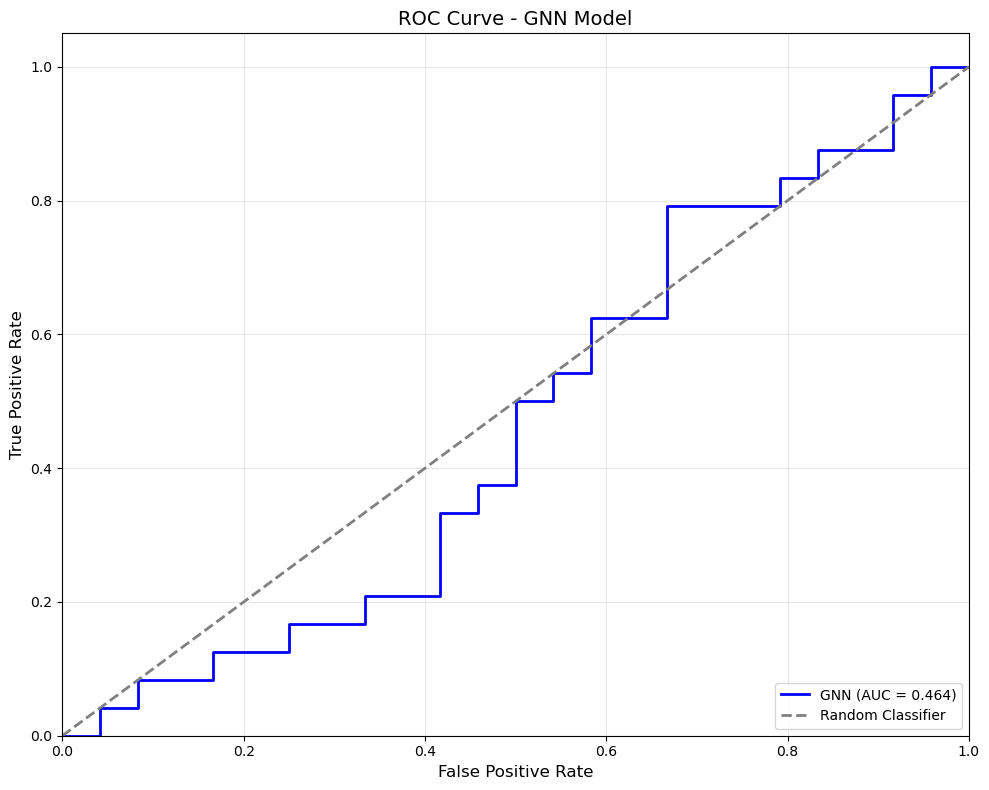


GNN Model AUC: 0.4635


In [59]:
# Load GNN predictions
gnn_predictions = pd.read_csv('../gnn/gnn_test_predictions.csv')
print(f"Loaded {len(gnn_predictions)} GNN predictions")

# Filter GNN predictions to match edges in edges_all_filtered
# Create a merge key for matching
edges_all_filtered['merge_key'] = edges_all_filtered['ENTITYA'] + '_' + edges_all_filtered['ENTITYB']
gnn_predictions['merge_key'] = gnn_predictions['source'] + '_' + gnn_predictions['target']

# Merge to get only matching edges
gnn_filtered = edges_all_filtered[['ENTITYA', 'ENTITYB', 'label', 'merge_key']].merge(
    gnn_predictions[['merge_key', 'prediction']], 
    on='merge_key', 
    how='inner'
)

print(f"Matched {len(gnn_filtered)} edges between GNN predictions and edges_all_filtered")
print(f"True edges: {(gnn_filtered['label'] == 'true').sum()}")
print(f"False edges: {(gnn_filtered['label'] == 'false').sum()}")

# Prepare data for ROC curve
y_true_gnn = (gnn_filtered['label'] == 'true').astype(int)
y_pred_gnn = gnn_filtered['prediction']

# Calculate ROC curve
from sklearn.metrics import roc_curve, auc
fpr_gnn, tpr_gnn, _ = roc_curve(y_true_gnn, y_pred_gnn)
roc_auc_gnn = auc(fpr_gnn, tpr_gnn)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr_gnn, tpr_gnn, color='blue', lw=2, label=f'GNN (AUC = {roc_auc_gnn:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - GNN Model', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nGNN Model AUC: {roc_auc_gnn:.4f}")

## Reload GLM-4.6 with filtered data

In [13]:
# Reload GLM-4.6 data with filtered ground truth
edges_all_glm_filtered = all_ground_truth_edges_filtered.copy(deep=True)

# Initialize answer columns for each repeat
for repeat in range(REPEAT_GLM):
    edges_all_glm_filtered[f'answer_{repeat}'] = None

for index, edge in all_ground_truth_edges_filtered.iterrows():
    # Get the edge data
    source = edge['ENTITYA']
    target = edge['ENTITYB']
    label = edge['label']
    
    for repeat in range(REPEAT_GLM):
        # False edges prediction
        if label == 'false':
            result_file = Path(f'./results/reasoning/{model_glm}/no_search/false_edges/{source}_{target}_repeat{repeat}.json')
        else:  # True edges
            result_file = Path(f'./results/reasoning/{model_glm}/no_search/true_edges/{source}_{target}_repeat{repeat}.json')
        
        # Check if file exists
        if result_file.exists():
            with open(result_file, 'r') as f:
                result_data = json.load(f)
            answer = result_data['answer']
            # Store answer in the DataFrame
            edges_all_glm_filtered.loc[index, f'answer_{repeat}'] = answer
        else:
            print(f"File not found: {result_file}")

# Check for NaN values
nan_counts_glm_filtered = edges_all_glm_filtered[[f'answer_{repeat}' for repeat in range(REPEAT_GLM)]].isna().sum()
print("NaN counts in answers for each repeat (GLM-4.6 filtered):")
print(nan_counts_glm_filtered)

NaN counts in answers for each repeat (GLM-4.6 filtered):
answer_0    0
answer_1    0
answer_2    0
answer_3    0
answer_4    0
answer_5    0
answer_6    0
answer_7    0
answer_8    0
answer_9    0
dtype: int64


## Plot ROC curves with filtered data

/tmp/ipykernel_3433405/2914279834.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_preds_all = edges_all_glm_filtered[prediction_columns].replace({True: 1.0, False: 0.0})


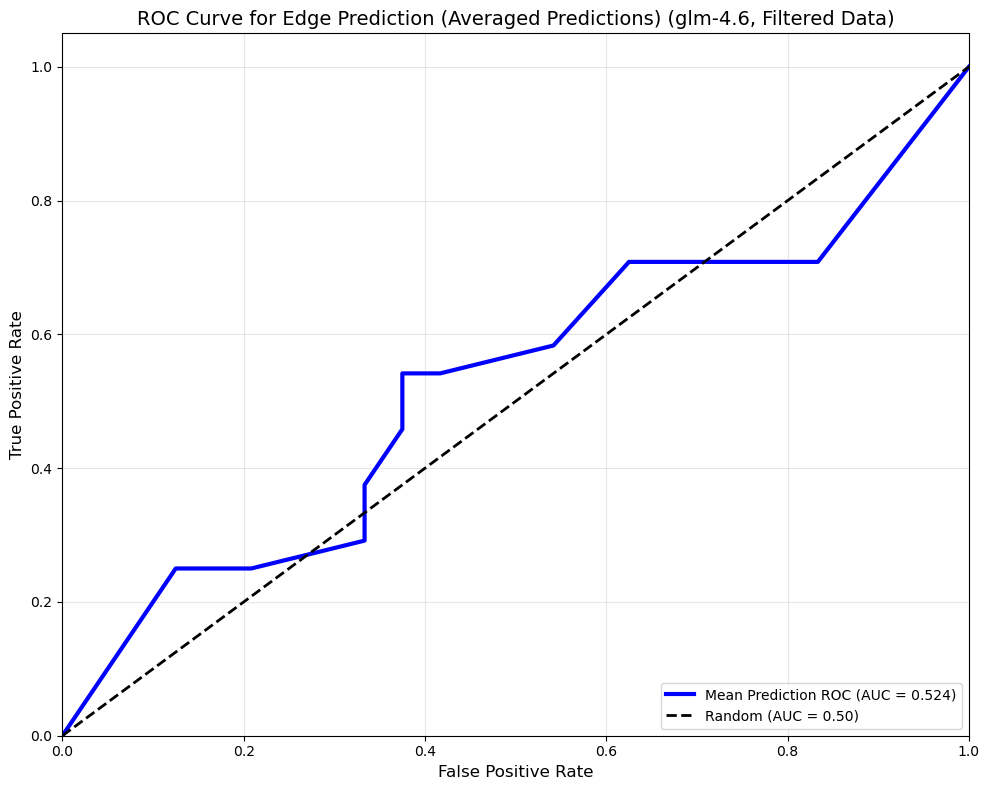

Mean Prediction AUC: 0.524


In [36]:
# Plot ROC curve for GLM-4.6 with filtered data (Averaged Predictions)
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for ROC curve
y_true_glm_filtered = (edges_all_glm_filtered['label'] == 'true').astype(int)

# Calculate mean prediction across repeats
prediction_columns = [f'answer_{i}' for i in range(REPEAT_GLM)]
# Ensure columns are numeric (True/False -> 1.0/0.0)
y_preds_all = edges_all_glm_filtered[prediction_columns].replace({True: 1.0, False: 0.0})
# Calculate mean across columns (axis=1)
y_pred_mean = y_preds_all.mean(axis=1)

# Remove rows with missing predictions
valid_mask = ~y_pred_mean.isna()
y_true_valid = y_true_glm_filtered[valid_mask]
y_pred_mean_valid = y_pred_mean[valid_mask]

# Calculate ROC curve
fpr_glm, tpr_glm, thresholds_glm = roc_curve(y_true_valid, y_pred_mean_valid)
roc_auc_glm = auc(fpr_glm, tpr_glm)

# Create figure for ROC curve
plt.figure(figsize=(10, 8))

# Plot mean ROC curve
plt.plot(fpr_glm, tpr_glm, color='b', linewidth=3, 
         label=f'Mean Prediction ROC (AUC = {roc_auc_glm:.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve for Edge Prediction (Averaged Predictions) ({model_glm}, Filtered Data)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print(f"Mean Prediction AUC: {roc_auc_glm:.3f}")

/tmp/ipykernel_3433405/2996400361.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_pred_mean = edges_all_filtered[answer_cols].replace({True: 1.0, False: 0.0}).mean(axis=1)


Found 10 answer columns for averaging: ['answer_0', 'answer_1', 'answer_2', 'answer_3', 'answer_4', 'answer_5', 'answer_6', 'answer_7', 'answer_8', 'answer_9']


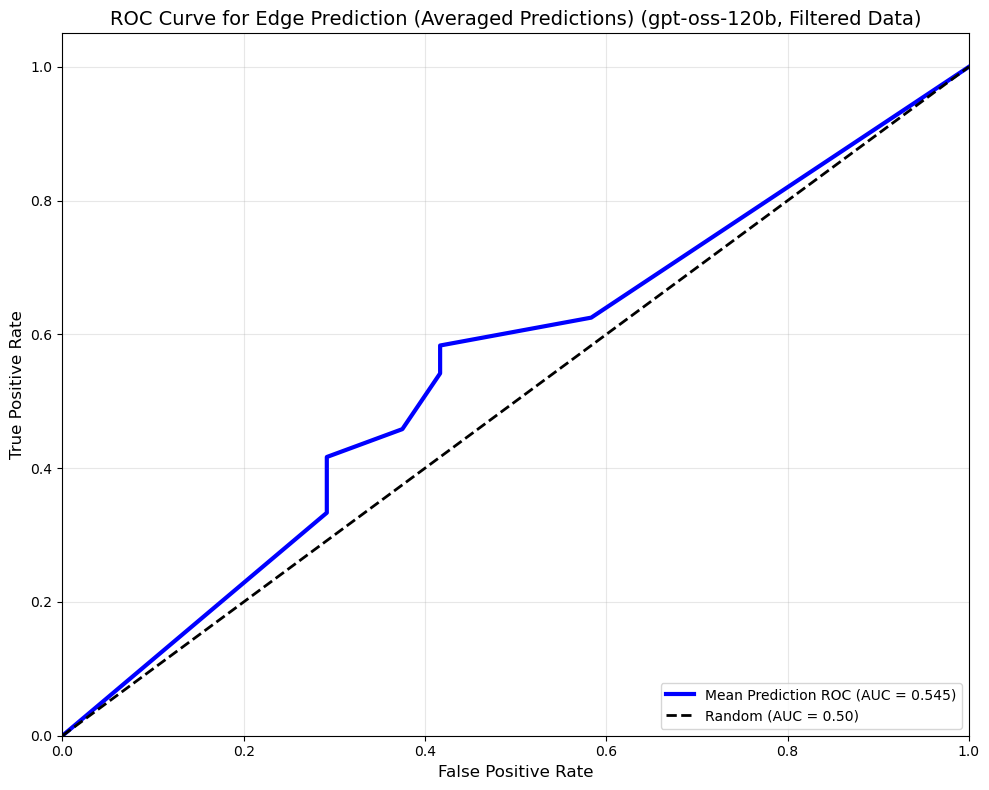

Mean Prediction AUC: 0.545


In [37]:
# Plot ROC curve for GPT-OSS-120B with filtered data (Averaged Predictions)
from sklearn.metrics import roc_curve, auc

# Prepare True Labels
y_true_filtered = (edges_all_filtered['label'] == 'true').astype(int)

# Calculate Mean Predictions across repeats
answer_cols = [col for col in edges_all_filtered.columns if col.startswith('answer_')]
print(f"Found {len(answer_cols)} answer columns for averaging: {answer_cols}")

# Convert True/False to 1.0/0.0 and calculate mean
y_pred_mean = edges_all_filtered[answer_cols].replace({True: 1.0, False: 0.0}).mean(axis=1)

# Remove rows with missing predictions (if any)
valid_mask = ~y_pred_mean.isna()
y_true_valid = y_true_filtered[valid_mask]
y_pred_mean_valid = y_pred_mean[valid_mask]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true_valid, y_pred_mean_valid)
roc_auc = auc(fpr, tpr)

# Create figure for ROC curve
plt.figure(figsize=(10, 8))

# Plot mean ROC curve
plt.plot(fpr, tpr, color='b', linewidth=3, 
         label=f'Mean Prediction ROC (AUC = {roc_auc:.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve for Edge Prediction (Averaged Predictions) ({model}, Filtered Data)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig(f'roc_curve_averaged_{model}_filtered_251117.pdf', bbox_inches='tight')
plt.show()

print(f"Mean Prediction AUC: {roc_auc:.3f}")

/tmp/ipykernel_3433405/2852268084.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_preds_all = edges_all_filtered[prediction_columns].replace({True: 1.0, False: 0.0})


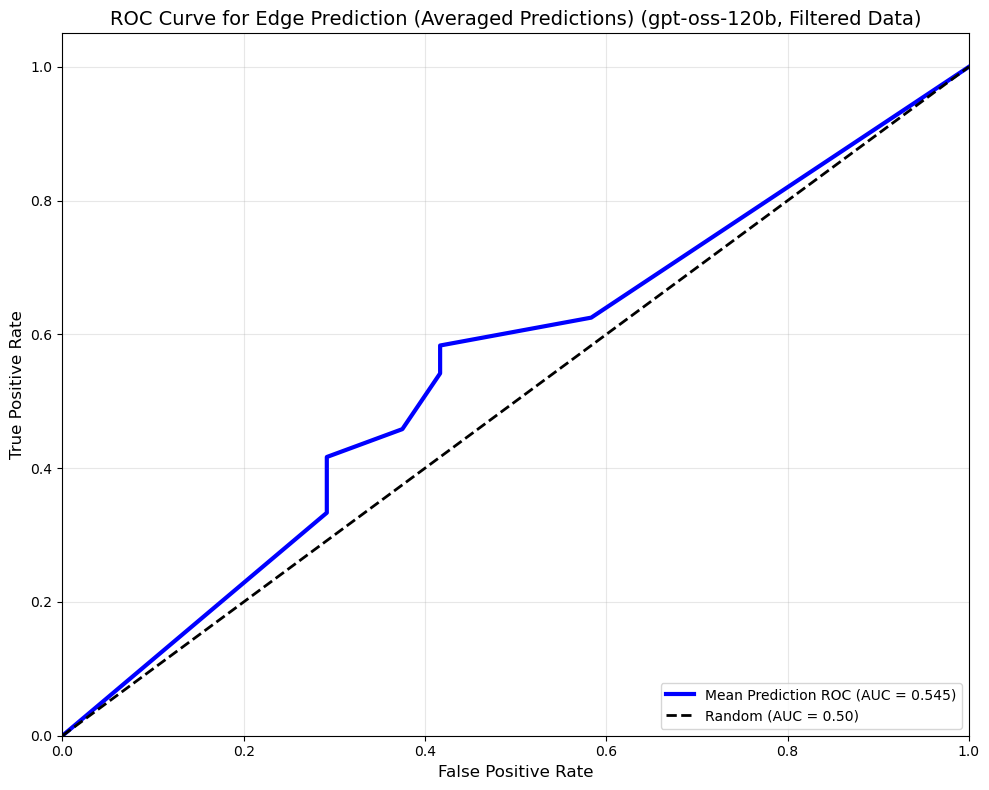

Mean Prediction AUC: 0.545


In [38]:
# Plot ROC curve for GPT-OSS-120B with filtered data (Averaged Predictions)
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for ROC curve
y_true_filtered = (edges_all_filtered['label'] == 'true').astype(int)

# Calculate mean prediction across repeats
prediction_columns = [f'answer_{i}' for i in range(REPEAT)]
# Ensure columns are numeric (True/False -> 1.0/0.0)
y_preds_all = edges_all_filtered[prediction_columns].replace({True: 1.0, False: 0.0})
# Calculate mean across columns (axis=1)
y_pred_mean = y_preds_all.mean(axis=1)

# Remove rows with missing predictions
valid_mask = ~y_pred_mean.isna()
y_true_valid = y_true_filtered[valid_mask]
y_pred_mean_valid = y_pred_mean[valid_mask]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true_valid, y_pred_mean_valid)
roc_auc = auc(fpr, tpr)

# Create figure for ROC curve
plt.figure(figsize=(10, 8))

# Plot mean ROC curve
plt.plot(fpr, tpr, color='b', linewidth=3, 
         label=f'Mean Prediction ROC (AUC = {roc_auc:.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve for Edge Prediction (Averaged Predictions) ({model}, Filtered Data)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
# plt.savefig(f'roc_curve_mean_{model}_filtered_251117.pdf', bbox_inches='tight')
plt.show()

print(f"Mean Prediction AUC: {roc_auc:.3f}")

In [39]:
# # Plot ROC curve for GLM-4.6 with filtered data
# y_true_glm_filtered = (edges_all_glm_filtered['label'] == 'true').astype(int)

# # Create figure for ROC curves
# plt.figure(figsize=(10, 8))

# # Store all FPR and TPR values for averaging
# all_fprs_glm_filtered = []
# all_tprs_glm_filtered = []

# # Plot ROC curve for each repeat
# auc_scores_glm_filtered = []
# for repeat in range(REPEAT_GLM):
#     # Get predictions for this repeat
#     y_pred = edges_all_glm_filtered[f'answer_{repeat}'].apply(lambda x: 1.0 if x == True else 0.0)
    
#     # Remove rows with missing predictions
#     valid_mask = ~y_pred.isna()
#     y_true_valid = y_true_glm_filtered[valid_mask]
#     y_pred_valid = y_pred[valid_mask]
    
#     # Calculate ROC curve
#     fpr, tpr, thresholds = roc_curve(y_true_valid, y_pred_valid)
#     roc_auc = auc(fpr, tpr)
#     auc_scores_glm_filtered.append(roc_auc)
    
#     # Store for averaging
#     all_fprs_glm_filtered.append(fpr)
#     all_tprs_glm_filtered.append(tpr)
    
#     # Plot individual curves with low alpha
#     plt.plot(fpr, tpr, alpha=0.2, color='gray', linewidth=1)

# # Compute mean ROC curve
# mean_fpr_glm_filtered = np.linspace(0, 1, 100)

# # Interpolate TPR values at these FPR points for each repeat
# interpolated_tprs_glm_filtered = []
# for fpr, tpr in zip(all_fprs_glm_filtered, all_tprs_glm_filtered):
#     interp_tpr = np.interp(mean_fpr_glm_filtered, fpr, tpr)
#     interpolated_tprs_glm_filtered.append(interp_tpr)

# # Calculate mean and std TPR
# mean_tpr_glm_filtered = np.mean(interpolated_tprs_glm_filtered, axis=0)
# std_tpr_glm_filtered = np.std(interpolated_tprs_glm_filtered, axis=0)

# # Ensure the curve starts at (0,0) and ends at (1,1)
# mean_tpr_glm_filtered[0] = 0.0
# mean_tpr_glm_filtered[-1] = 1.0

# # Calculate AUC for mean curve
# mean_auc_glm_filtered = auc(mean_fpr_glm_filtered, mean_tpr_glm_filtered)

# # Plot mean ROC curve
# plt.plot(mean_fpr_glm_filtered, mean_tpr_glm_filtered, color='b', linewidth=3, 
#          label=f'Mean ROC (AUC = {mean_auc_glm_filtered:.3f} ± {np.std(auc_scores_glm_filtered):.3f})')

# # Plot diagonal (random classifier)
# plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)')

# plt.xlabel('False Positive Rate', fontsize=12)
# plt.ylabel('True Positive Rate', fontsize=12)
# plt.title(f'ROC Curves for Edge Prediction ({model_glm}, Filtered Data)', fontsize=14)
# plt.legend(loc='lower right', fontsize=10)
# plt.grid(alpha=0.3)
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.tight_layout()
# plt.savefig(f'roc_curve_mean_{model_glm}_filtered_251117.pdf', bbox_inches='tight')
# plt.show()

# print(f"\nIndividual AUC scores: {[f'{score:.3f}' for score in auc_scores_glm_filtered]}")
# print(f"Mean AUC: {np.mean(auc_scores_glm_filtered):.3f} ± {np.std(auc_scores_glm_filtered):.3f}")
# print(f"Mean curve AUC: {mean_auc_glm_filtered:.3f}")

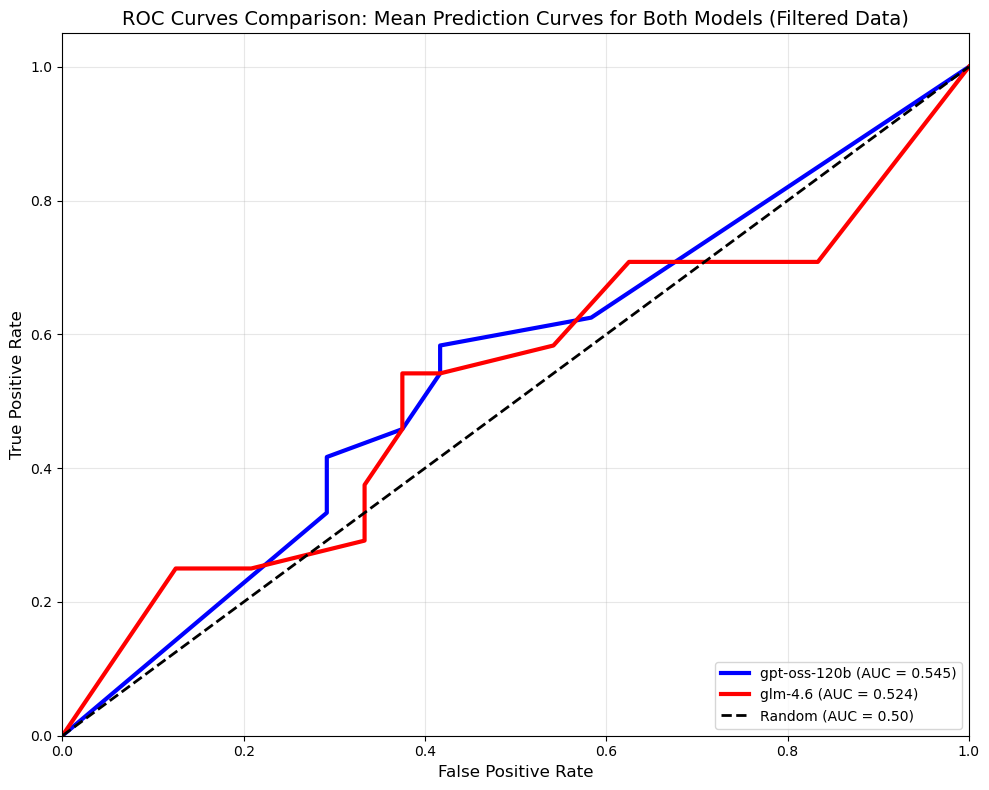


Model Comparison (Filtered Data):

gpt-oss-120b:
  Mean Prediction AUC: 0.545

glm-4.6:
  Mean Prediction AUC: 0.524



In [40]:
# Combined plot with both models' average ROC curves (FILTERED DATA)
plt.figure(figsize=(10, 8))

# Plot gpt-oss-120b mean ROC curve
plt.plot(fpr, tpr, color='b', linewidth=3, 
         label=f'{model} (AUC = {roc_auc:.3f})')

# Plot glm-4.6 mean ROC curve
plt.plot(fpr_glm, tpr_glm, color='r', linewidth=3, 
         label=f'{model_glm} (AUC = {roc_auc_glm:.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison: Mean Prediction Curves for Both Models (Filtered Data)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig('roc_curve_comparison_both_models_filtered.pdf', bbox_inches='tight')
plt.show()

# Print comparison statistics
print(f"\n{'='*60}")
print(f"Model Comparison (Filtered Data):")
print(f"{'='*60}")
print(f"\n{model}:")
print(f"  Mean Prediction AUC: {roc_auc:.3f}")
print(f"\n{model_glm}:")
print(f"  Mean Prediction AUC: {roc_auc_glm:.3f}")
print(f"\n{'='*60}")

## Load GPT-OSS-20B with filtered data

In [52]:
# Load data for gpt-oss-20b model
REPEAT_GPT20B = 10
model_gpt20b = 'gpt-oss-20b'
edges_all_gpt20b_filtered = all_ground_truth_edges_filtered.copy(deep=True)

# Initialize answer columns for each repeat
for repeat in range(REPEAT_GPT20B):
    edges_all_gpt20b_filtered[f'answer_{repeat}'] = None

for index, edge in all_ground_truth_edges_filtered.iterrows():
    # Get the edge data
    source = edge['ENTITYA']
    target = edge['ENTITYB']
    label = edge['label']
    
    for repeat in range(REPEAT_GPT20B):
        # False edges prediction
        if label == 'false':
            result_file = Path(f'./results/reasoning/{model_gpt20b}/no_search/false_edges/{source}_{target}_repeat{repeat}.json')
        else:  # True edges
            result_file = Path(f'./results/reasoning/{model_gpt20b}/no_search/true_edges/{source}_{target}_repeat{repeat}.json')
        
        # Check if file exists
        if result_file.exists():
            with open(result_file, 'r') as f:
                result_data = json.load(f)
            answer = result_data['answer']
            # Store answer in the DataFrame
            edges_all_gpt20b_filtered.loc[index, f'answer_{repeat}'] = answer
        else:
            print(f"File not found: {result_file}")

# Check for NaN values
nan_counts_gpt20b_filtered = edges_all_gpt20b_filtered[[f'answer_{repeat}' for repeat in range(REPEAT_GPT20B)]].isna().sum()
print("NaN counts in answers for each repeat (GPT-OSS-20B filtered):")
print(nan_counts_gpt20b_filtered)

NaN counts in answers for each repeat (GPT-OSS-20B filtered):
answer_0    0
answer_1    0
answer_2    0
answer_3    0
answer_4    0
answer_5    0
answer_6    0
answer_7    0
answer_8    0
answer_9    0
dtype: int64


In [53]:
# # Plot ROC curve for GPT-OSS-20B with filtered data (Averaged Predictions)
# from sklearn.metrics import roc_curve, auc

# # Prepare True Labels
# y_true_gpt20b_filtered = (edges_all_gpt20b_filtered['label'] == 'true').astype(int)

# # Calculate Averaged Predictions
# prediction_columns = [f'answer_{i}' for i in range(REPEAT_GPT20B)]
# # Ensure all prediction columns are numeric (0.0 or 1.0)
# for col in prediction_columns:
#     edges_all_gpt20b_filtered[col] = edges_all_gpt20b_filtered[col].apply(lambda x: 1.0 if x == True else 0.0)

# # Calculate mean prediction across repeats for each edge
# y_pred_mean = edges_all_gpt20b_filtered[prediction_columns].mean(axis=1)

# # Remove rows with missing predictions (if any)
# valid_mask = ~y_pred_mean.isna()
# y_true_valid = y_true_gpt20b_filtered[valid_mask]
# y_pred_mean_valid = y_pred_mean[valid_mask]

# # Calculate Single ROC Curve on Averaged Predictions
# fpr, tpr, thresholds = roc_curve(y_true_valid, y_pred_mean_valid)
# roc_auc = auc(fpr, tpr)

# # Plot
# plt.figure(figsize=(10, 8))
# plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Mean Prediction ROC (AUC = {roc_auc:.3f})')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.50)')

# plt.xlabel('False Positive Rate', fontsize=12)
# plt.ylabel('True Positive Rate', fontsize=12)
# plt.title(f'ROC Curve for Edge Prediction ({model_gpt20b}, Filtered Data) - Averaged Predictions', fontsize=14)
# plt.legend(loc='lower right', fontsize=10)
# plt.grid(alpha=0.3)
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.tight_layout()
# plt.savefig(f'roc_curve_averaged_{model_gpt20b}_filtered_251117.pdf', bbox_inches='tight')
# plt.show()

# print(f"Averaged Prediction ROC AUC: {roc_auc:.3f}")


/tmp/ipykernel_3433405/2275596014.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_preds_all = edges_all_gpt20b_filtered[prediction_columns].replace({True: 1.0, False: 0.0})


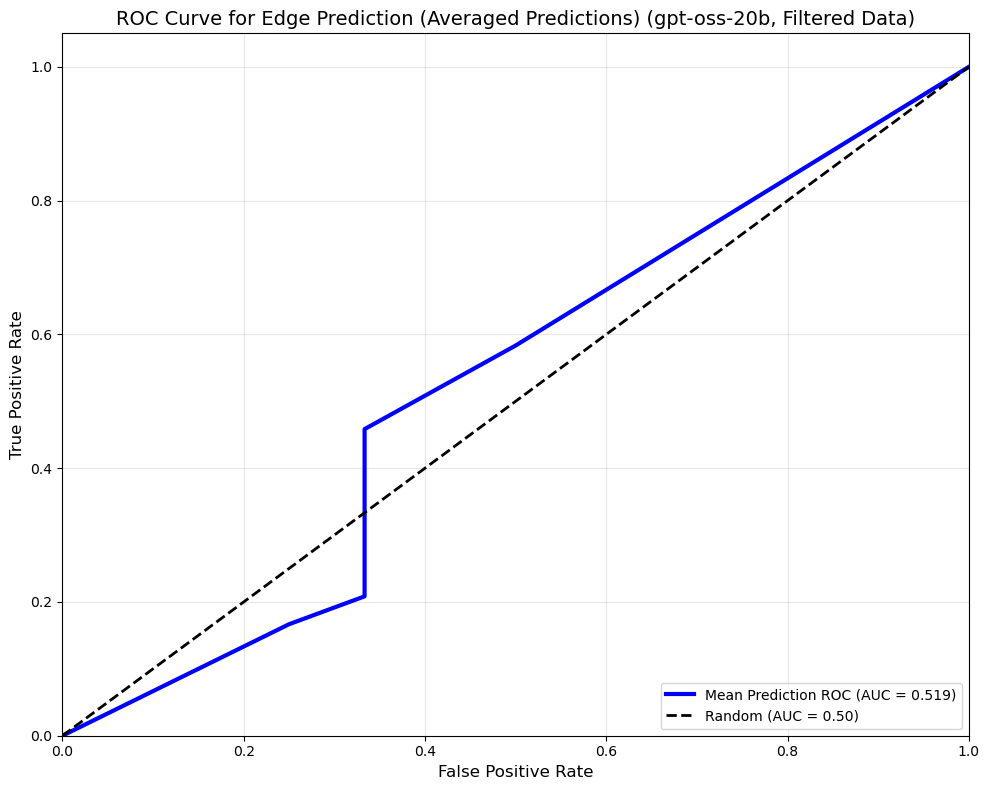

Mean Prediction AUC: 0.519


In [54]:
# Plot ROC curve for GPT-OSS-20B with filtered data (Averaged Predictions)
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for ROC curve
y_true_gpt20b_filtered = (edges_all_gpt20b_filtered['label'] == 'true').astype(int)

# Calculate mean prediction across repeats
prediction_columns = [f'answer_{i}' for i in range(REPEAT_GPT20B)]
# Ensure columns are numeric (True/False -> 1.0/0.0)
y_preds_all = edges_all_gpt20b_filtered[prediction_columns].replace({True: 1.0, False: 0.0})
# Calculate mean across columns (axis=1)
y_pred_mean = y_preds_all.mean(axis=1)

# Remove rows with missing predictions
valid_mask = ~y_pred_mean.isna()
y_true_valid = y_true_gpt20b_filtered[valid_mask]
y_pred_mean_valid = y_pred_mean[valid_mask]

# Calculate ROC curve
fpr_gpt20b, tpr_gpt20b, thresholds_gpt20b = roc_curve(y_true_valid, y_pred_mean_valid)
roc_auc_gpt20b = auc(fpr_gpt20b, tpr_gpt20b)

# Create figure for ROC curve
plt.figure(figsize=(10, 8))

# Plot mean ROC curve
plt.plot(fpr_gpt20b, tpr_gpt20b, color='b', linewidth=3, 
         label=f'Mean Prediction ROC (AUC = {roc_auc_gpt20b:.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve for Edge Prediction (Averaged Predictions) ({model_gpt20b}, Filtered Data)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig(f'roc_curve_mean_{model_gpt20b}_filtered_251117.pdf', bbox_inches='tight')
plt.show()

print(f"Mean Prediction AUC: {roc_auc_gpt20b:.3f}")

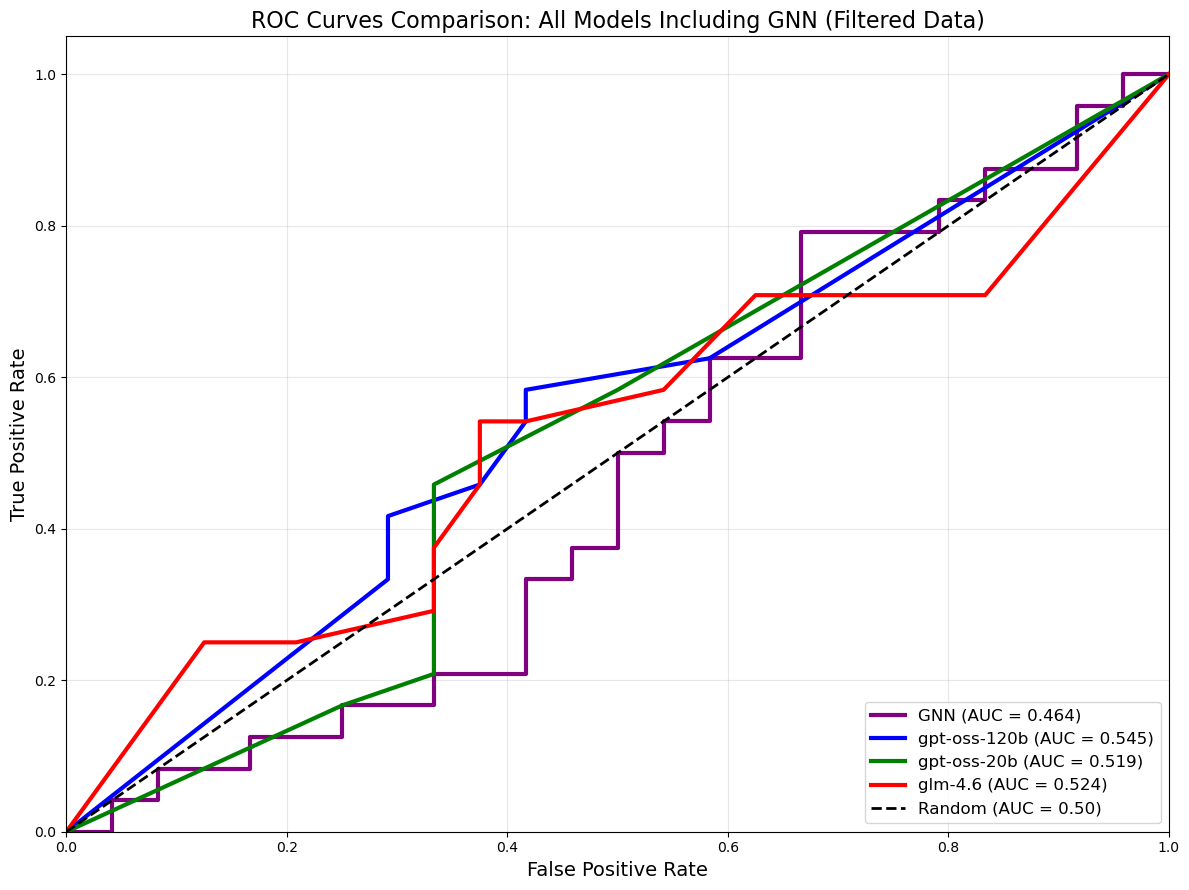


Model Comparison (Filtered Data):

GNN:
  AUC: 0.464

gpt-oss-120b:
  Mean Prediction AUC: 0.545

gpt-oss-20b:
  Mean Prediction AUC: 0.519

glm-4.6:
  Mean Prediction AUC: 0.524


AUC Rankings:
1. gpt-oss-120b: 0.545
2. glm-4.6: 0.524
3. gpt-oss-20b: 0.519
4. GNN: 0.464


In [62]:
# Combined plot with all four models' average ROC curves (FILTERED DATA) including GNN
plt.figure(figsize=(12, 9))

# Plot GNN ROC curve
plt.plot(fpr_gnn, tpr_gnn, color='purple', linewidth=3, 
         label=f'GNN (AUC = {roc_auc_gnn:.3f})')

# Plot gpt-oss-120b mean ROC curve
plt.plot(fpr, tpr, color='b', linewidth=3, 
         label=f'{model} (AUC = {roc_auc:.3f})')

# Plot gpt-oss-20b mean ROC curve
plt.plot(fpr_gpt20b, tpr_gpt20b, color='g', linewidth=3, 
         label=f'{model_gpt20b} (AUC = {roc_auc_gpt20b:.3f})')

# Plot glm-4.6 mean ROC curve
plt.plot(fpr_glm, tpr_glm, color='r', linewidth=3, 
         label=f'{model_glm} (AUC = {roc_auc_glm:.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curves Comparison: All Models Including GNN (Filtered Data)', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig('roc_curve_comparison_all_models_with_gnn_filtered.pdf', bbox_inches='tight')
plt.show()

# Print comparison statistics
print(f"\n{'='*60}")
print(f"Model Comparison (Filtered Data):")
print(f"{'='*60}")
print(f"\nGNN:")
print(f"  AUC: {roc_auc_gnn:.3f}")
print(f"\n{model}:")
print(f"  Mean Prediction AUC: {roc_auc:.3f}")
print(f"\n{model_gpt20b}:")
print(f"  Mean Prediction AUC: {roc_auc_gpt20b:.3f}")
print(f"\n{model_glm}:")
print(f"  Mean Prediction AUC: {roc_auc_glm:.3f}")
print(f"\n{'='*60}")
print(f"\nAUC Rankings:")
aucs = [
    ('GNN', roc_auc_gnn),
    (model, roc_auc),
    (model_gpt20b, roc_auc_gpt20b),
    (model_glm, roc_auc_glm)
]
aucs_sorted = sorted(aucs, key=lambda x: x[1], reverse=True)
for i, (name, auc_val) in enumerate(aucs_sorted, 1):
    print(f"{i}. {name}: {auc_val:.3f}")
print(f"{'='*60}")

# Heatmap

In [56]:
gpt_oss_120b_false_edges = edges_all_filtered[edges_all_filtered['label'] == 'false']

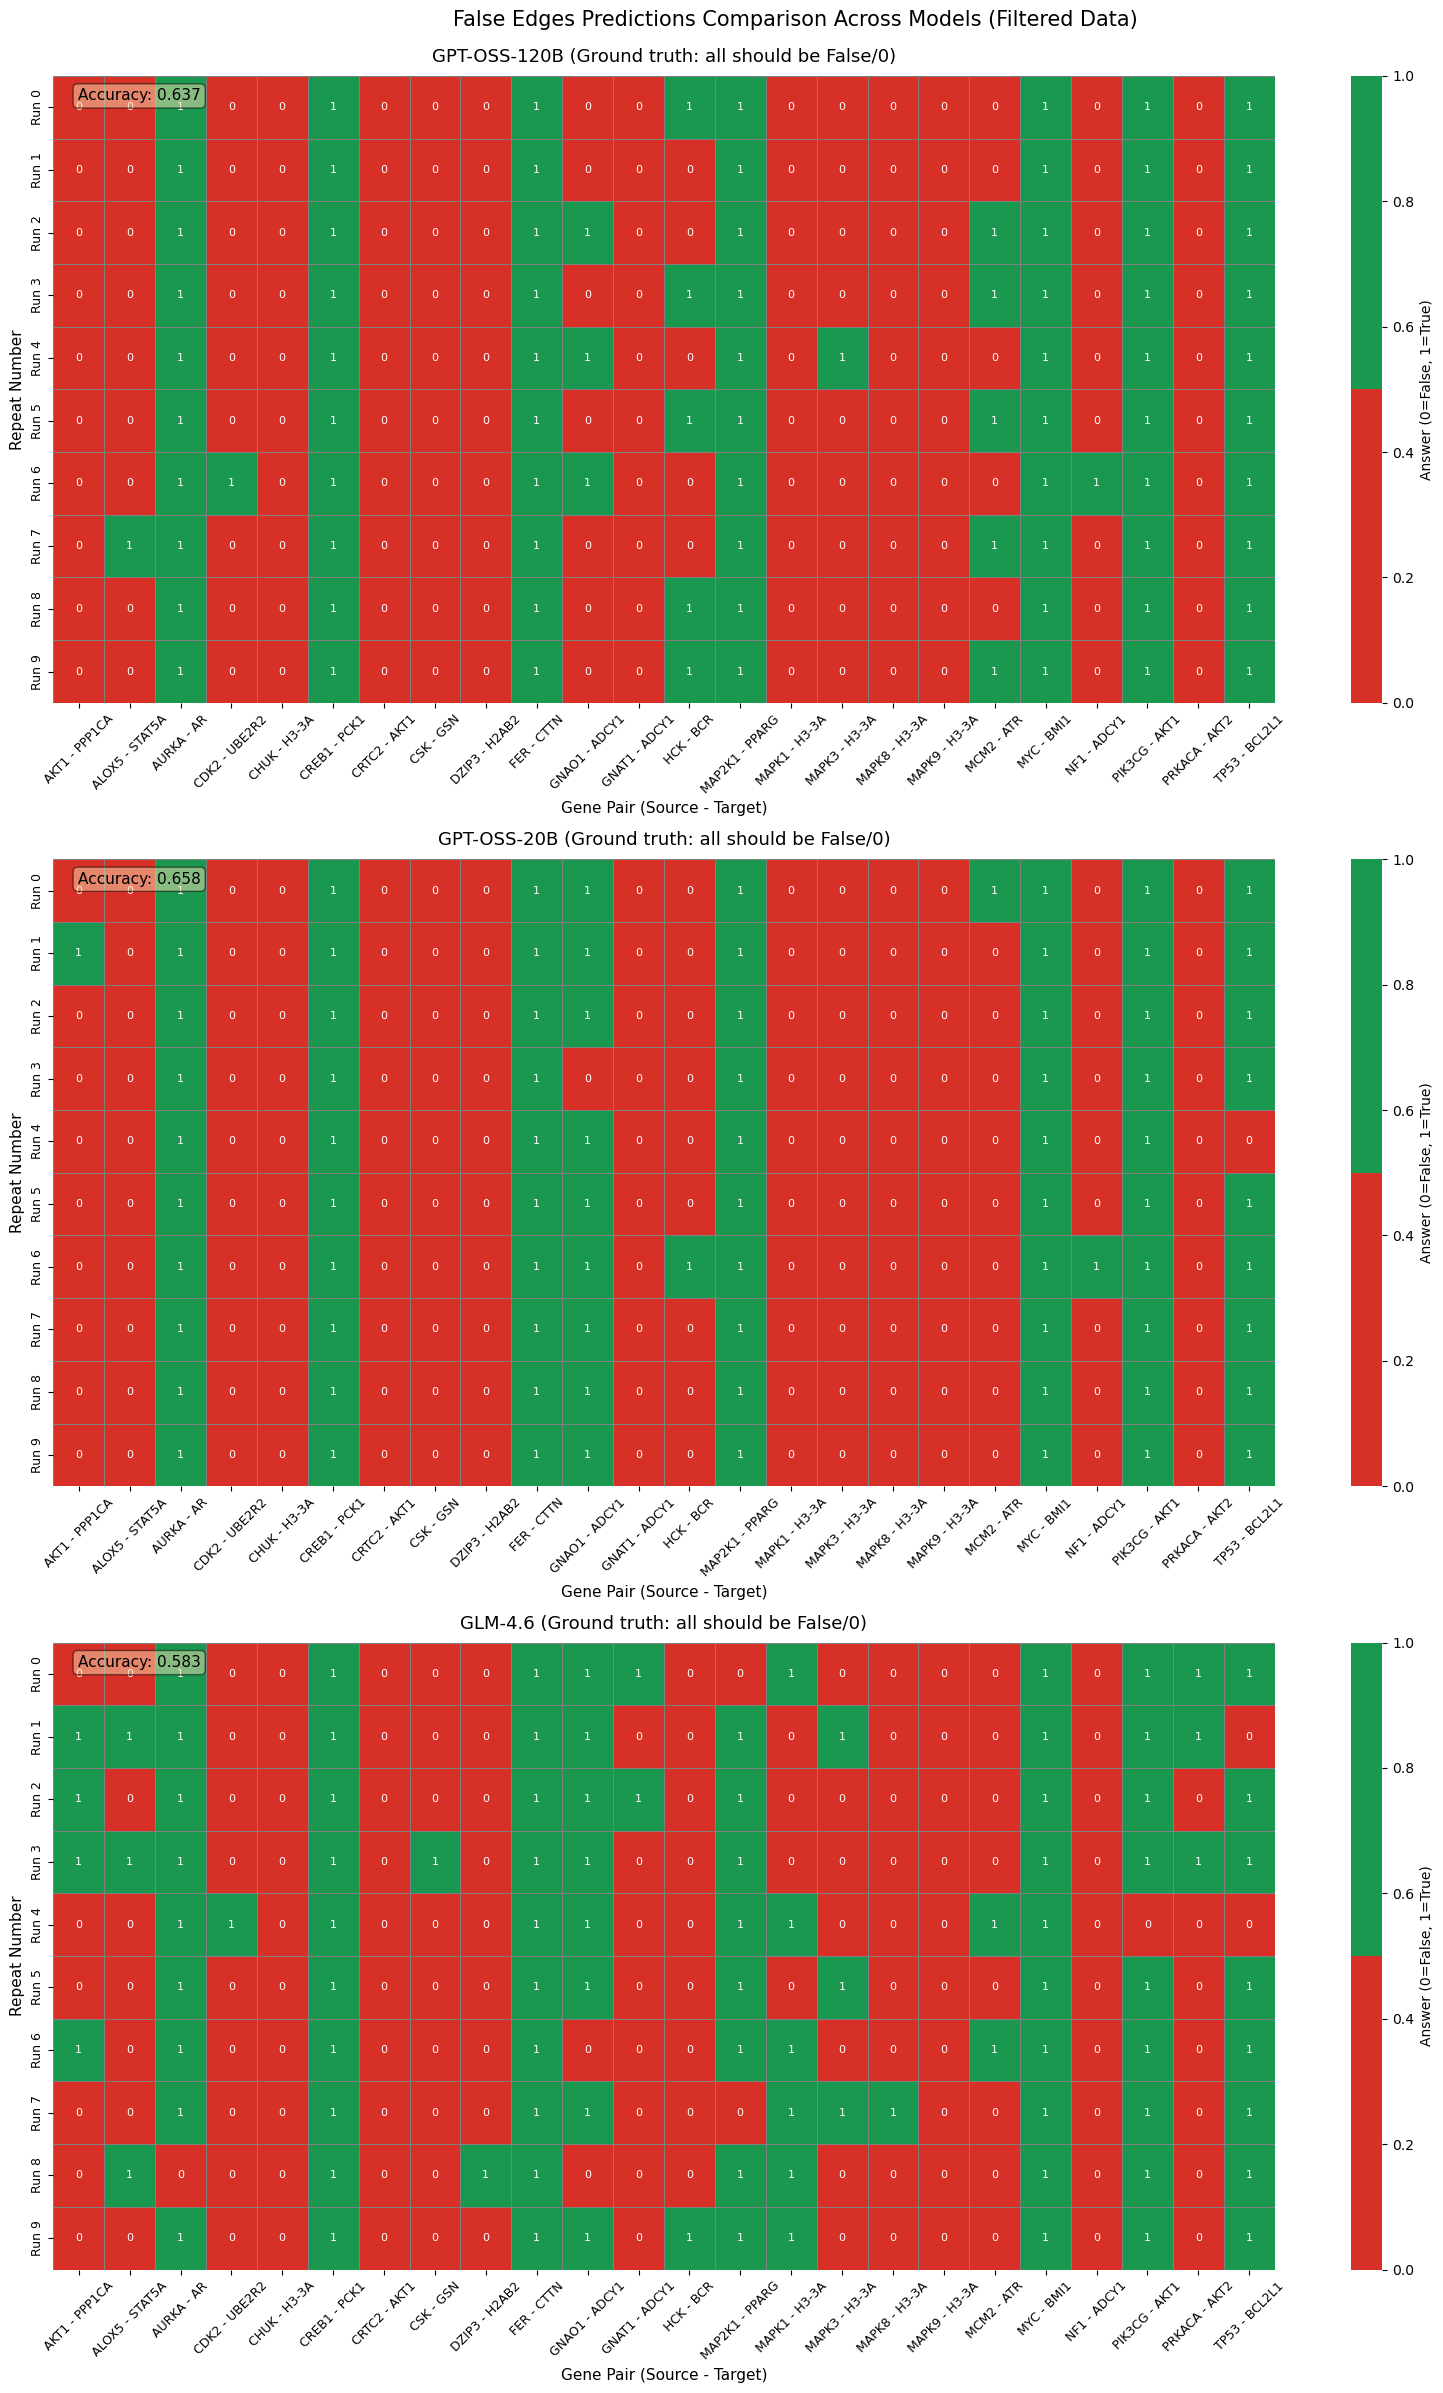


False Edges Prediction Accuracy Comparison:

GPT-OSS-120B:
  Correct predictions (False): 153/240
  Accuracy: 0.637

GPT-OSS-20B:
  Correct predictions (False): 158/240
  Accuracy: 0.658

GLM-4.6:
  Correct predictions (False): 140/240
  Accuracy: 0.583

Number of gene pairs: 24
Number of repeats: GPT-OSS-120B=10, GPT-OSS-20B=10, GLM-4.6=10


In [61]:
from matplotlib.colors import ListedColormap

# Create comparison heatmap for all three models (false edges only)
# Extract false edges for each model
gpt120b_false = edges_all_filtered[edges_all_filtered['label'] == 'false']
gpt20b_false = edges_all_gpt20b_filtered[edges_all_gpt20b_filtered['label'] == 'false']
glm_false = edges_all_glm_filtered[edges_all_glm_filtered['label'] == 'false']

# Get gene pairs from filtered data
gene_pairs_heatmap = []
for index, edge in gpt120b_false.iterrows():
    source = edge['ENTITYA']
    target = edge['ENTITYB']
    gene_pairs_heatmap.append((source, target))

# Sort gene pairs alphabetically
gene_pairs_heatmap = sorted(gene_pairs_heatmap, key=lambda x: (x[0], x[1]))
gene_pair_labels_heatmap = [f"{source} - {target}" for source, target in gene_pairs_heatmap]

# Function to create answer matrix
def create_answer_matrix(edges_df, gene_pairs, num_repeats):
    answer_matrix = []
    for source, target in gene_pairs:
        mask = (edges_df['ENTITYA'] == source) & (edges_df['ENTITYB'] == target)
        edge_data = edges_df[mask]
        if len(edge_data) > 0:
            row_answers = []
            for repeat in range(num_repeats):
                answer = edge_data.iloc[0][f'answer_{repeat}']
                # Convert to int: True=1, False=0
                row_answers.append(1 if answer == True else 0)
            answer_matrix.append(row_answers)
    return np.array(answer_matrix)

# Create answer matrices for all three models
answer_matrix_gpt120b = create_answer_matrix(gpt120b_false, gene_pairs_heatmap, REPEAT)
answer_matrix_gpt20b = create_answer_matrix(gpt20b_false, gene_pairs_heatmap, REPEAT_GPT20B)
answer_matrix_glm = create_answer_matrix(glm_false, gene_pairs_heatmap, REPEAT_GLM)

# Create figure with three subplots (vertical layout: 3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(16, 24))

# Plot GPT-OSS-120B
sns.heatmap(answer_matrix_gpt120b.T,
            xticklabels=gene_pair_labels_heatmap,
            yticklabels=[f"Run {i}" for i in range(answer_matrix_gpt120b.shape[1])],
            cmap=ListedColormap(['#d73027', '#1a9850']),  # Red for 0/False, Green for 1/True,
            vmin=0, vmax=1,
            cbar_kws={'label': 'Answer (0=False, 1=True)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,
            fmt='.0f',
            annot_kws={'fontsize': 8},
            ax=axes[0])
axes[0].set_title('GPT-OSS-120B (Ground truth: all should be False/0)', fontsize=13, pad=10)
axes[0].set_xlabel('Gene Pair (Source - Target)', fontsize=11)
axes[0].set_ylabel('Repeat Number', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', labelsize=9)

# Calculate and display accuracy for GPT-OSS-120B
correct_gpt120b = np.sum(answer_matrix_gpt120b == 0)
total_gpt120b = answer_matrix_gpt120b.size
acc_gpt120b = correct_gpt120b / total_gpt120b
axes[0].text(0.02, 0.98, f'Accuracy: {acc_gpt120b:.3f}', 
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot GPT-OSS-20B
sns.heatmap(answer_matrix_gpt20b.T,
            xticklabels=gene_pair_labels_heatmap,
            yticklabels=[f"Run {i}" for i in range(answer_matrix_gpt20b.shape[1])],
            cmap=ListedColormap(['#d73027', '#1a9850']),  # Red for 0/False, Green for 1/True,
            vmin=0, vmax=1,
            cbar_kws={'label': 'Answer (0=False, 1=True)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,
            fmt='.0f',
            annot_kws={'fontsize': 8},
            ax=axes[1])
axes[1].set_title('GPT-OSS-20B (Ground truth: all should be False/0)', fontsize=13, pad=10)
axes[1].set_xlabel('Gene Pair (Source - Target)', fontsize=11)
axes[1].set_ylabel('Repeat Number', fontsize=11)
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
axes[1].tick_params(axis='y', labelsize=9)

# Calculate and display accuracy for GPT-OSS-20B
correct_gpt20b = np.sum(answer_matrix_gpt20b == 0)
total_gpt20b = answer_matrix_gpt20b.size
acc_gpt20b = correct_gpt20b / total_gpt20b
axes[1].text(0.02, 0.98, f'Accuracy: {acc_gpt20b:.3f}', 
             transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot GLM-4.6
sns.heatmap(answer_matrix_glm.T,
            xticklabels=gene_pair_labels_heatmap,
            yticklabels=[f"Run {i}" for i in range(answer_matrix_glm.shape[1])],
            cmap=ListedColormap(['#d73027', '#1a9850']),  # Red for 0/False, Green for 1/True,
            vmin=0, vmax=1,
            cbar_kws={'label': 'Answer (0=False, 1=True)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,
            fmt='.0f',
            annot_kws={'fontsize': 8},
            ax=axes[2])
axes[2].set_title('GLM-4.6 (Ground truth: all should be False/0)', fontsize=13, pad=10)
axes[2].set_xlabel('Gene Pair (Source - Target)', fontsize=11)
axes[2].set_ylabel('Repeat Number', fontsize=11)
axes[2].tick_params(axis='x', rotation=45, labelsize=9)
axes[2].tick_params(axis='y', labelsize=9)

# Calculate and display accuracy for GLM-4.6
correct_glm = np.sum(answer_matrix_glm == 0)
total_glm = answer_matrix_glm.size
acc_glm = correct_glm / total_glm
axes[2].text(0.02, 0.98, f'Accuracy: {acc_glm:.3f}', 
             transform=axes[2].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('False Edges Predictions Comparison Across Models (Filtered Data)', fontsize=15, y=0.995)
plt.tight_layout()
plt.savefig('false_edges_heatmap_comparison_all_models_251117.pdf', bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\n{'='*70}")
print(f"False Edges Prediction Accuracy Comparison:")
print(f"{'='*70}")
print(f"\nGPT-OSS-120B:")
print(f"  Correct predictions (False): {correct_gpt120b}/{total_gpt120b}")
print(f"  Accuracy: {acc_gpt120b:.3f}")
print(f"\nGPT-OSS-20B:")
print(f"  Correct predictions (False): {correct_gpt20b}/{total_gpt20b}")
print(f"  Accuracy: {acc_gpt20b:.3f}")
print(f"\nGLM-4.6:")
print(f"  Correct predictions (False): {correct_glm}/{total_glm}")
print(f"  Accuracy: {acc_glm:.3f}")
print(f"\n{'='*70}")
print(f"Number of gene pairs: {len(gene_pairs_heatmap)}")
print(f"Number of repeats: GPT-OSS-120B={REPEAT}, GPT-OSS-20B={REPEAT_GPT20B}, GLM-4.6={REPEAT_GLM}")
print(f"{'='*70}")

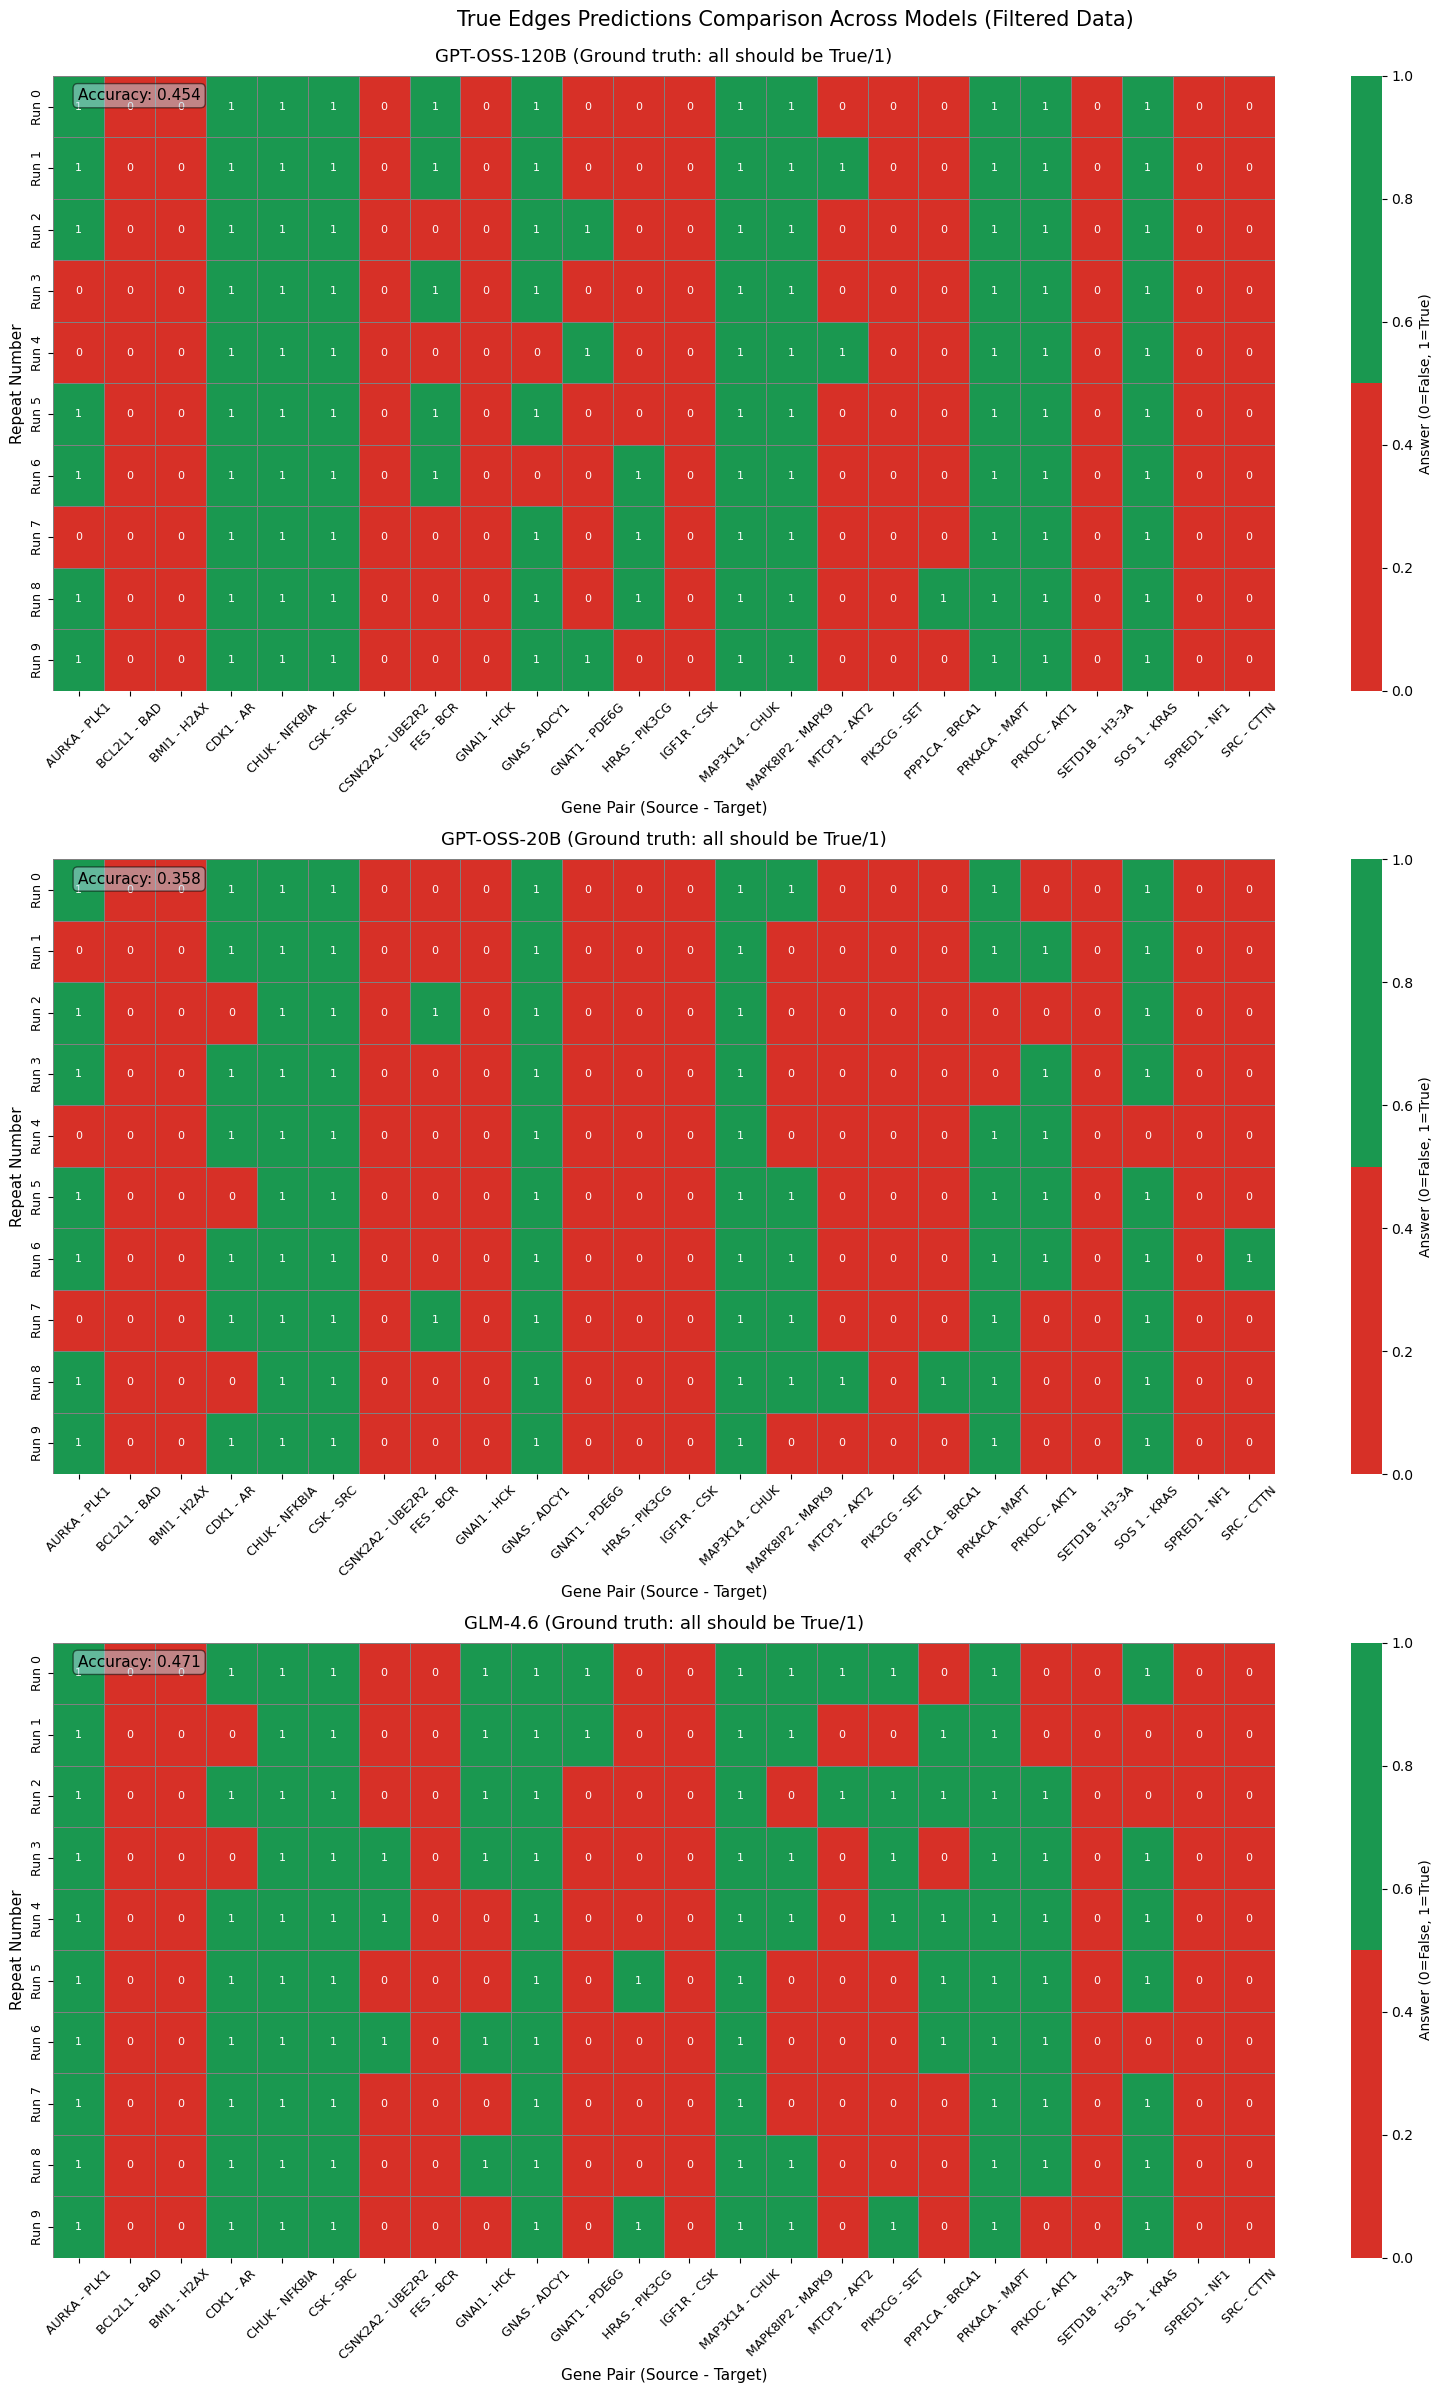


True Edges Prediction Accuracy Comparison:

GPT-OSS-120B:
  Correct predictions (True): 109/240
  Accuracy: 0.454

GPT-OSS-20B:
  Correct predictions (True): 86/240
  Accuracy: 0.358

GLM-4.6:
  Correct predictions (True): 113/240
  Accuracy: 0.471

Number of gene pairs: 24
Number of repeats: GPT-OSS-120B=10, GPT-OSS-20B=10, GLM-4.6=10


In [58]:
from matplotlib.colors import ListedColormap

# Create comparison heatmap for all three models (true edges only)
# Extract true edges for each model
gpt120b_true = edges_all_filtered[edges_all_filtered['label'] == 'true']
gpt20b_true = edges_all_gpt20b_filtered[edges_all_gpt20b_filtered['label'] == 'true']
glm_true = edges_all_glm_filtered[edges_all_glm_filtered['label'] == 'true']

# Get gene pairs from filtered data
gene_pairs_heatmap_true = []
for index, edge in gpt120b_true.iterrows():
    source = edge['ENTITYA']
    target = edge['ENTITYB']
    gene_pairs_heatmap_true.append((source, target))

# Sort gene pairs alphabetically
gene_pairs_heatmap_true = sorted(gene_pairs_heatmap_true, key=lambda x: (x[0], x[1]))
gene_pair_labels_heatmap_true = [f"{source} - {target}" for source, target in gene_pairs_heatmap_true]

# Create answer matrices for all three models (reusing the function defined earlier)
answer_matrix_gpt120b_true = create_answer_matrix(gpt120b_true, gene_pairs_heatmap_true, REPEAT)
answer_matrix_gpt20b_true = create_answer_matrix(gpt20b_true, gene_pairs_heatmap_true, REPEAT_GPT20B)
answer_matrix_glm_true = create_answer_matrix(glm_true, gene_pairs_heatmap_true, REPEAT_GLM)

# Create figure with three subplots (vertical layout: 3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(16, 24))

# Plot GPT-OSS-120B
sns.heatmap(answer_matrix_gpt120b_true.T,
            xticklabels=gene_pair_labels_heatmap_true,
            yticklabels=[f"Run {i}" for i in range(answer_matrix_gpt120b_true.shape[1])],
            cmap=ListedColormap(['#d73027', '#1a9850']),  # Red for 0/False, Green for 1/True,
            vmin=0, vmax=1,
            cbar_kws={'label': 'Answer (0=False, 1=True)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,
            fmt='.0f',
            annot_kws={'fontsize': 8},
            ax=axes[0])
axes[0].set_title('GPT-OSS-120B (Ground truth: all should be True/1)', fontsize=13, pad=10)
axes[0].set_xlabel('Gene Pair (Source - Target)', fontsize=11)
axes[0].set_ylabel('Repeat Number', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', labelsize=9)

# Calculate and display accuracy for GPT-OSS-120B
correct_gpt120b_true = np.sum(answer_matrix_gpt120b_true == 1)
total_gpt120b_true = answer_matrix_gpt120b_true.size
acc_gpt120b_true = correct_gpt120b_true / total_gpt120b_true
axes[0].text(0.02, 0.98, f'Accuracy: {acc_gpt120b_true:.3f}', 
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Plot GPT-OSS-20B
sns.heatmap(answer_matrix_gpt20b_true.T,
            xticklabels=gene_pair_labels_heatmap_true,
            yticklabels=[f"Run {i}" for i in range(answer_matrix_gpt20b_true.shape[1])],
            cmap=ListedColormap(['#d73027', '#1a9850']),  # Red for 0/False, Green for 1/True,
            vmin=0, vmax=1,
            cbar_kws={'label': 'Answer (0=False, 1=True)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,
            fmt='.0f',
            annot_kws={'fontsize': 8},
            ax=axes[1])
axes[1].set_title('GPT-OSS-20B (Ground truth: all should be True/1)', fontsize=13, pad=10)
axes[1].set_xlabel('Gene Pair (Source - Target)', fontsize=11)
axes[1].set_ylabel('Repeat Number', fontsize=11)
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
axes[1].tick_params(axis='y', labelsize=9)

# Calculate and display accuracy for GPT-OSS-20B
correct_gpt20b_true = np.sum(answer_matrix_gpt20b_true == 1)
total_gpt20b_true = answer_matrix_gpt20b_true.size
acc_gpt20b_true = correct_gpt20b_true / total_gpt20b_true
axes[1].text(0.02, 0.98, f'Accuracy: {acc_gpt20b_true:.3f}', 
             transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Plot GLM-4.6
sns.heatmap(answer_matrix_glm_true.T,
            xticklabels=gene_pair_labels_heatmap_true,
            yticklabels=[f"Run {i}" for i in range(answer_matrix_glm_true.shape[1])],
            cmap=ListedColormap(['#d73027', '#1a9850']),  # Red for 0/False, Green for 1/True,
            vmin=0, vmax=1,
            cbar_kws={'label': 'Answer (0=False, 1=True)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,
            fmt='.0f',
            annot_kws={'fontsize': 8},
            ax=axes[2])
axes[2].set_title('GLM-4.6 (Ground truth: all should be True/1)', fontsize=13, pad=10)
axes[2].set_xlabel('Gene Pair (Source - Target)', fontsize=11)
axes[2].set_ylabel('Repeat Number', fontsize=11)
axes[2].tick_params(axis='x', rotation=45, labelsize=9)
axes[2].tick_params(axis='y', labelsize=9)

# Calculate and display accuracy for GLM-4.6
correct_glm_true = np.sum(answer_matrix_glm_true == 1)
total_glm_true = answer_matrix_glm_true.size
acc_glm_true = correct_glm_true / total_glm_true
axes[2].text(0.02, 0.98, f'Accuracy: {acc_glm_true:.3f}', 
             transform=axes[2].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.suptitle('True Edges Predictions Comparison Across Models (Filtered Data)', fontsize=15, y=0.995)
plt.tight_layout()
plt.savefig('true_edges_heatmap_comparison_all_models_251117.pdf', bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\n{'='*70}")
print(f"True Edges Prediction Accuracy Comparison:")
print(f"{'='*70}")
print(f"\nGPT-OSS-120B:")
print(f"  Correct predictions (True): {correct_gpt120b_true}/{total_gpt120b_true}")
print(f"  Accuracy: {acc_gpt120b_true:.3f}")
print(f"\nGPT-OSS-20B:")
print(f"  Correct predictions (True): {correct_gpt20b_true}/{total_gpt20b_true}")
print(f"  Accuracy: {acc_gpt20b_true:.3f}")
print(f"\nGLM-4.6:")
print(f"  Correct predictions (True): {correct_glm_true}/{total_glm_true}")
print(f"  Accuracy: {acc_glm_true:.3f}")
print(f"\n{'='*70}")
print(f"Number of gene pairs: {len(gene_pairs_heatmap_true)}")
print(f"Number of repeats: GPT-OSS-120B={REPEAT}, GPT-OSS-20B={REPEAT_GPT20B}, GLM-4.6={REPEAT_GLM}")
print(f"{'='*70}")